# TNG300-1: z=10 descendants and COLIBRE Fig. 7–8 comparison

新しい独立 notebook。元の `tng300_z8_descendant_mass.ipynb` は変更しません。

1. **Halo selection**: $10^{10.8}<M_{200c}(z=10)/M_\odot<10^{11.2}$ の FoF central を追跡し、$p(\log_{10}M_{200c,0}^{\rm host})$ と z=8 比較を作る。
2. **Galaxy selection**: 全 subhalo に $M_\star(z=10)>9\times10^6M_\odot$ を適用（halo mass cut を重ねない）。別に $M_\star>10^9M_\odot$ の保守的な比較を作る。閾値は編集可能。
3. **Fig. 7 analogue**: fate fractions、survivor stellar-mass relation、fate ごとの descendant host PDF [dex$^{-1}$]。真正の減光後 UV データがあれば $M_{\rm UV,attn}<-18$ subset を追加。
4. **Fig. 8 analogue**: z=8,5,1,0 の descendant host mass vs z=10 host mass、median と 16–84 percentile。halo-selected と galaxy-selected を別図にする。

**比較上の限界**: COLIBRE は HBT-HERONS の persistent TrackID と 50 pkpc aperture stellar mass を使用する。本 notebook の survival は SubLink の全 forward edge で `FirstProgenitorID == current SubhaloID` が保たれるかによる **proxy**。同じ物理的 galaxy の厳密な同定ではない。枝が途中終了した object の z=0 host は tree から取得できず、その PDF の欠損率を明示する。I/O error や tree 未収録を disruption に数えない。PDF は各 fate 内で host mass が判明した object に条件づける。

COLIBRE の Fig. 8 は **galaxy-selected / progenitor-weighted**。halo-selected の狭い $10^{11}M_\odot$ bin は z=8 比較用であり、COLIBRE の全サンプルと同一ではない。EPS 曲線は計算しない（ここでは simulation 側の比較図を作る）。TNG の低質量領域は表示しても収束を保証しない。

出典: [Zhao et al. 2026, arXiv:2608.23558](https://arxiv.org/abs/2608.23558), Fig. 7–8 / §2.3–2.4; ユーザー指定 PDF の p.9 を確認。
[TNG field specifications](https://www.tng-project.org/data/docs/specifications/) /
[official SubLink reader](https://github.com/illustristng/illustris_python/blob/master/illustris_python/sublink.py).

## 1. Imports and configuration
上から Run All。実データの group catalogs (snapshots 4,8,17,50,99)、snapshot-4 offsets と SubLink trees が必要。50 pkpc mode には選択 galaxy の star particle cutouts も必要。

In [1]:
from pathlib import Path
from collections import OrderedDict
import os, json, warnings
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from tqdm.auto import tqdm
try:
    import illustris_python as il
except ImportError as exc:
    raise ImportError("Install the official illustris_python package in this notebook's kernel.") from exc

plt.rcParams.update({'figure.dpi': 120, 'font.size': 15, 'axes.grid': False,
                     'grid.alpha': 0.2, 'figure.constrained_layout.use': True})

In [2]:
# Overrides allow the same notebook to run on a server or a local mount.
BASE_PATH = os.environ.get('TNG_OUTPUT_DIR')  # or edit to '/home/tnguser/sims.TNG/L205n2500TNG/output'
cwd = Path.cwd().resolve()
proto_root = next((p / 'protohalo' for p in [cwd, *cwd.parents]
                   if (p / 'protohalo' / 'notebooks').is_dir()), None)
if proto_root is None:
    proto_root = cwd.parent if cwd.name == 'notebooks' else cwd
data_dir = proto_root / 'data'
out_dir = Path(os.environ.get('TNG_ANALYSIS_DIR', str(data_dir / 'tng300_z10_colibre'))).expanduser()
fig_dir = out_dir / 'figures'

snap_start = 4
epochs = {8: 8, 5: 17, 1: 50, 0: 99}  # target redshift -> snapshot
logM_min, logM_max = 10.8, 11.2
MSTAR_FIDUCIAL = 9e6
MSTAR_CONSERVATIVE = 1e9  # ~90 initial TNG300-1 baryonic mass elements; NOT a convergence proof
REQUIRE_SUBHALO_FLAG = True
STELLAR_MASS_MODE = 'bound'  # 'bound' (catalog) or '50pkpc' (particle-based spherical aperture)
UV_CSV = data_dir / 'tng300_z10_uv_attn.csv'
UV_METADATA = UV_CSV.with_suffix('.json')
# Optional independently obtained z=0 hosts for terminated tracks. Never infer them from last host.
DISRUPTED_HOST_CSV = None  # columns: SubhaloID_z10, GroupID_z0; document particle-tracing method below
DISRUPTED_HOST_PROVENANCE = ''
MIN_BIN_N = 10
PDF_BIN_WIDTH = 0.2
initial_mass_edges = np.arange(8.8, 12.01, 0.2)
RELIABILITY_GUIDE_LOGM = 10.8  # visual guide only; not a universal z=10 convergence threshold

candidates = [Path(BASE_PATH).expanduser()] if BASE_PATH else [
    Path('/home/tnguser/sims.TNG/L205n2500TNG/output'),
    Path('/home/tnguser/sims.TNG/TNG300-1/output'),
    *[p / 'sims.TNG' / sim / 'output' for p in [cwd, *cwd.parents]
      for sim in ('TNG300-1', 'L205n2500TNG')],
]
basePath = next((p.resolve() for p in candidates if p.is_dir()), None)
if basePath is None:
    raise FileNotFoundError('Set BASE_PATH or TNG_OUTPUT_DIR to TNG300-1/output. No simulation found.')
if STELLAR_MASS_MODE not in ('bound', '50pkpc'):
    raise ValueError('Invalid STELLAR_MASS_MODE')
assert 0 < MSTAR_FIDUCIAL <= MSTAR_CONSERVATIVE
assert PDF_BIN_WIDTH > 0 and MIN_BIN_N > 0
fig_dir.mkdir(parents=True, exist_ok=True)
headers = {s: il.groupcat.loadHeader(str(basePath), s) for s in [snap_start, *epochs.values()]}
h_values = [float(v['HubbleParam']) for v in headers.values() if 'HubbleParam' in v]
h = h_values[0] if h_values else 0.6774
if not h_values:
    print('Groupcat headers do not include h: using the documented TNG cosmology h=0.6774.')
assert np.isclose(h, 0.6774, atol=1e-4, rtol=0)
assert all(np.isclose(h, v) for v in h_values)
assert abs(float(headers[4]['Redshift']) - 10) < 0.15
assert abs(float(headers[99]['Redshift'])) < 1e-5
for z, s in epochs.items():
    assert abs(float(headers[s]['Redshift']) - z) < 0.15
print('Simulation:', basePath, '\nOutput:', out_dir)
display(pd.DataFrame([{'snapshot': s, 'redshift': float(v['Redshift'])} for s,v in headers.items()]))

# Tracking performance and persistent checkpoints (independent of stellar/UV selection).
TRACK_BLOCK_ROWS = 16384
TRACK_MEMORY_MB = 128  # NumPy tree block LRU; excludes catalogs and HDF5 internal caches
# Same excluded cache root as protohalo_particle_cache; separate files for tree traces.
TRACK_CACHE_DIR = Path(os.environ.get(
    'TNG_TRACK_CACHE_DIR', str(proto_root / 'cache' / 'sublink_tracking_cache')
)).expanduser()
LEGACY_TRACK_CACHE_DIR = out_dir / 'tracking_cache'
TRACK_COMMIT_EVERY = 100
TRACK_COMMIT_SECONDS = 10
RETRY_CACHED_ERRORS = True


Simulation: /home/tnguser/sims.TNG/L205n2500TNG/output 
Output: /home/tnguser/tng-work/protohalo/data/tng300_z10_colibre


,snapshot,redshift
0,4,9.996590e+00
1,8,8.012173e+00
2,17,4.995933e+00
3,50,9.972942e-01
4,99,2.220446e-16


## 2. Catalogs and stellar mass
Mass conversion: catalog code mass $\times10^{10}/h \rightarrow M_\odot$.
`bound` uses `SubhaloMassType[:,4]` and is an aperture mismatch with COLIBRE.
`50pkpc` sums **formed stars only** (`GFM_StellarFormationTime > 0`) within 50 physical kpc of `SubhaloPos`, with periodic positions and $a/h$ conversion. It sums bound subhalo particles; any difference in SOAP particle membership remains. `SubhaloLenType[:,4]` is a diagnostic count of stars **and winds**, not an exact formed-star count.

In [3]:
def load_catalog(s):
    halos = il.groupcat.loadHalos(str(basePath), s, fields=['Group_M_Crit200', 'GroupFirstSub'])
    sub = il.groupcat.loadSubhalos(str(basePath), s, fields=[
        'SubhaloGrNr', 'SubhaloMassType', 'SubhaloLenType', 'SubhaloFlag', 'SubhaloPos'])
    masses = np.asarray(halos['Group_M_Crit200'], dtype=float) * 1e10 / h
    first = np.asarray(halos['GroupFirstSub'], dtype=np.int64)
    group = np.asarray(sub['SubhaloGrNr'], dtype=np.int64)
    if np.any((group < 0) | (group >= len(masses))):
        raise ValueError(f'Invalid SubhaloGrNr at snapshot {s}')
    return {'mass': masses, 'first': first, 'group': group,
            'mstar': np.asarray(sub['SubhaloMassType'])[:,4] * 1e10 / h,
            'npart4': np.asarray(sub['SubhaloLenType'])[:,4],
            'flag': np.asarray(sub['SubhaloFlag'], dtype=bool),
            'pos': np.asarray(sub['SubhaloPos'])}

catalogs = {s: load_catalog(s) for s in headers}
stellar_cache = {}
def stellar_mass(s, sid):
    key = (int(s), int(sid))
    if STELLAR_MASS_MODE == 'bound':
        return float(catalogs[s]['mstar'][sid])
    if key not in stellar_cache:
        stars = il.snapshot.loadSubhalo(str(basePath), s, sid, 'stars', fields=[
            'Coordinates', 'Masses', 'GFM_StellarFormationTime'])
        if stars.get('count', 0) == 0:
            stellar_cache[key] = 0.0
        else:
            box = float(headers[s]['BoxSize'])
            delta = np.asarray(stars['Coordinates']) - catalogs[s]['pos'][sid]
            delta -= box * np.rint(delta / box)
            r_pkpc = np.linalg.norm(delta, axis=1) / (h * (1 + float(headers[s]['Redshift'])))
            keep = (np.asarray(stars['GFM_StellarFormationTime']) > 0) & (r_pkpc <= 50)
            stellar_cache[key] = float(np.asarray(stars['Masses'])[keep].sum() * 1e10 / h)
    return stellar_cache[key]

def safe_log(x):
    x = np.asarray(x, dtype=float)
    out = np.full(x.shape, np.nan)
    w = np.isfinite(x) & (x > 0)
    out[w] = np.log10(x[w])
    return out

c4 = catalogs[4]
group_logm = safe_log(c4['mass'])
halo_groups = np.flatnonzero((group_logm > logM_min) & (group_logm < logM_max)
                            & (c4['first'] >= 0))
halo_ids = c4['first'][halo_groups]
if np.any(halo_ids >= len(c4['group'])) or not np.all(c4['group'][halo_ids] == halo_groups):
    raise ValueError('Invalid central-to-host mapping at z=10')
# An aperture mass cannot exceed the total bound mass; prefilter avoids particle reads for tiny objects.
gal_candidate = np.flatnonzero((c4['mstar'] > MSTAR_FIDUCIAL)
                              & (c4['flag'] | (not REQUIRE_SUBHALO_FLAG)))
gal_mstar = np.array([stellar_mass(4, int(sid)) for sid in tqdm(gal_candidate, desc='z=10 stellar mass')])
gal_ids = gal_candidate[gal_mstar > MSTAR_FIDUCIAL]
seed_ids = np.union1d(halo_ids, gal_ids).astype(np.int64)
if len(seed_ids) == 0:
    raise RuntimeError('Both selections are empty. Check catalogs and units.')
seeds = pd.DataFrame({'SubhaloID_z10': seed_ids, 'GroupID_z10': c4['group'][seed_ids]})
seeds['M200c_z10'] = c4['mass'][seeds.GroupID_z10.to_numpy()]
seeds['logM200c_z10'] = safe_log(seeds.M200c_z10)
seeds['Mstar_z10'] = [stellar_mass(4, int(sid)) for sid in seed_ids]
seeds['logMstar_z10'] = safe_log(seeds.Mstar_z10)
seeds['Npart4_z10'] = c4['npart4'][seed_ids]
seeds['HaloSelected'] = np.isin(seed_ids, halo_ids)
seeds['GalaxyFiducial'] = np.isin(seed_ids, gal_ids)
seeds['GalaxyConservative'] = seeds.GalaxyFiducial & (seeds.Mstar_z10 > MSTAR_CONSERVATIVE)
print('Halo-selected:', int(seeds.HaloSelected.sum()), 'Galaxy fiducial:', int(seeds.GalaxyFiducial.sum()),
      'Galaxy conservative:', int(seeds.GalaxyConservative.sum()))
print('Fiducial stellar cut / nominal initial baryon mass ≈', MSTAR_FIDUCIAL / 1.1e7)
display(seeds.groupby('GalaxyFiducial')['Npart4_z10'].describe())

z=10 stellar mass:   0%|          | 0/57205 [00:00<?, ?it/s]

Halo-selected: 145 Galaxy fiducial: 57205 Galaxy conservative: 3
Fiducial stellar cut / nominal initial baryon mass ≈ 0.8181818181818182


,count,mean,std,min,25%,50%,75%,max
GalaxyFiducial,,,,,,,,
True,57205.0,2.045206,6.013863,1.0,1.0,1.0,2.0,422.0


## 3. Optional genuine UV catalog
TNG `SubhaloStellarPhotometrics` の8 bands は U,B,V,K,g,r,i,z。U-band、SFR proxy、intrinsic UV を減光後 UV として代用しない。

`UV_CSV` は `SubhaloID_z10,MUV_attn`。同名 `.json` は
`{"simulation":"TNG300-1","snapshot":4,"rest_frame":true,"dust_attenuated":true,"magnitude_system":"AB","wavelength_angstrom":1500,"provenance":"radiative-transfer method, view direction, aperture, source file"}`。
CSV の NaN は測定欠損。対象 ID の重複、範囲外 ID、metadata mismatch は停止する。coverage <100% の UV comparison は観測値のある parent に条件づけた追加図を作り、欠損による selection bias を明記する。

In [4]:
seeds['MUV_attn'] = np.nan
uv_info = {'available': False}
if UV_CSV.is_file():
    if not UV_METADATA.is_file():
        raise FileNotFoundError(f'UV provenance metadata required: {UV_METADATA}')
    uv_info = json.loads(UV_METADATA.read_text())
    expected = {'simulation':'TNG300-1', 'snapshot':4, 'rest_frame':True,
                'dust_attenuated':True, 'magnitude_system':'AB'}
    for k,v in expected.items():
        if uv_info.get(k) != v:
            raise ValueError(f'UV metadata mismatch: {k}')
    if not (1400 <= float(uv_info.get('wavelength_angstrom', 0)) <= 1600) or not uv_info.get('provenance'):
        raise ValueError('Specify rest-frame UV band and nonempty provenance.')
    uv = pd.read_csv(UV_CSV)
    if not {'SubhaloID_z10','MUV_attn'}.issubset(uv.columns):
        raise ValueError('Missing UV columns')
    ids = pd.to_numeric(uv.SubhaloID_z10, errors='raise')
    if ids.isna().any() or ((ids % 1) != 0).any() or ids.duplicated().any() or ((ids < 0) | (ids >= len(c4['group']))).any():
        raise ValueError('Invalid or duplicate UV IDs')
    uv['SubhaloID_z10'] = ids.astype(np.int64)
    uv['MUV_attn'] = pd.to_numeric(uv.MUV_attn, errors='raise')
    if np.isinf(uv.MUV_attn).any():
        raise ValueError('Infinite UV magnitude')
    seeds['MUV_attn'] = seeds.SubhaloID_z10.map(uv.set_index('SubhaloID_z10').MUV_attn)
    uv_info['available'] = True
seeds['UVKnown'] = np.isfinite(seeds.MUV_attn)
seeds['UVBright'] = seeds.GalaxyFiducial & seeds.UVKnown & (seeds.MUV_attn < -18)
for flag in ['GalaxyFiducial','GalaxyConservative']:
    q = seeds.loc[seeds[flag]]
    print(flag, ': N=',len(q), ', UV known=', int(q.UVKnown.sum()), ', UV bright=',int(q.UVBright.sum()))
if not uv_info['available']:
    print('No dust-attenuated UV catalog: UV subset is unavailable; mass-selected figures still run.')

GalaxyFiducial : N= 57205 , UV known= 0 , UV bright= 0
GalaxyConservative : N= 3 , UV known= 0 , UV bright= 0
No dust-attenuated UV catalog: UV subset is unavailable; mass-selected figures still run.


## 4. Forward pointer tracking and survival proxy
SubLink `SubhaloID` は global tree ID、`SubfindID` は snapshot 内の catalog index。混同しない。
公式 reader の `treeOffsets` と file offsets を使い、同一 tree file 内の depth-first contiguous IDs を通して **必要な row だけ**読む。大きな `onlyMDB=True` cutout を seed ごとにロードしない。

各 `DescendantID` edge を辿り、future row の `FirstProgenitorID` が current ID と一致しなくなった時点から merged proxy とする。一度合流した object は独立 survivor に戻さない。z=0 に到達した receiving galaxy/host は merged component にも割り当てる。`DescendantID == -1` で z=0 前に終了した valid track は disrupted proxy。ただし最終 host は不明。snapshot skip で指定 epoch の row がない場合は補間せず missing とする。

`not_in_tree`、invalid IDs、I/O exceptions は **unresolved**。unresolved を含む stacked fraction を示し、3 fate だけの図が不完全な時にそれを隠さない。FirstProgenitor の定義は treeName に依存するため、HBT-HERONS 分類とは異なる。

### 高速化と再開

HDF5 は5つの必要 fields を `TRACK_BLOCK_ROWS=16384` 行ずつ NumPy 配列に読み、以後の pointer walk はメモリ内で行う。block LRU の上限は `TRACK_MEMORY_MB=128` MiB（catalog arrays は別）。全 tree を一度にメモリに載せない。速度は storage と seed の局在に依存する。

各 seed の結果を `protohalo/cache/sublink_tracking_cache/traces_<fingerprint>.sqlite3` に逐次保存。100 seed ごと、または10秒経過後の seed 完了時に commit。通常の Interrupt は finally で完了済み seed を commit する。kernel の強制終了では最後の未commit batch が失われる可能性がある。再実行では完了済み seed をロードし、未完了 seed だけ追跡する。`error:*` は既定で再試行し、`not_in_tree` と正常な途中終了は再利用する。

Cache fingerprint は tree files と snapshot-4 offsets の path/size/mtime、z=0 subhalo-to-host / central mapping、epochs と追跡定義の version を含む。selection、UV、stellar aperture を変更しても同じ seed の tree trace は再利用できる。files を size/mtime を保ったまま差し替えた場合や独自に追跡定義を編集した場合は `TRACKER_CACHE_VERSION` を更新する。旧キャッシュを上書きせず新しいファイルを作る。

初回の offset setup / NumPy block 読込時間は progress bar の seed ETA に含まれない場合がある。**これは tree trace のキャッシュ**であり、catalog 読込や50 pkpc stellar particle 読込を永続キャッシュするものではない。

旧版の list comprehension をすでに実行中の場合、その処理には後から cache を追加できない。旧セル完了後に `records` が残っていれば下の `seed_checkpoint_from_records(records)` で取り込める。旧セルを途中 Interrupt すると、その list の完了部分は通常 `records` に代入されていない。


remote Jupyter の **10.00 GB は kernel 全体の上限**。複数 snapshot の catalog、DataFrame、描画用配列も使用するので、tree block cache は既定の128 MiBに維持する。実際にメモリ使用量の余裕を確認した場合は `TRACK_MEMORY_MB` を256/512などへ増やせるが、上限を10 GBまで割り当てない。大きくしても storage のアクセス局在によっては速度が変わらない。

永続キャッシュは、既存 `protohalo_particle_cache` と同じ `protohalo/cache/` の下の **別ディレクトリ** `sublink_tracking_cache` に保存する。この repository の `.gitignore` は `protohalo/cache/` を除外済み。ローカルコピー除外の設定もこの親ディレクトリ全体に適用されていることを使用環境で確認する（`.gitignore` 自体は任意のコピーコマンドを制御しない）。保存先は `TNG_TRACK_CACHE_DIR` で上書き可能。

以前の `out_dir/tracking_cache/` に同じ fingerprint のキャッシュがある場合、新しい保存先に SQLite backup で引き継ぐ（WAL の commit 済みデータも含む）。元ファイルは削除しない。現在実行中のセルの保存先は、そのセルが使用している設定のまま。


In [5]:
TREE_NAME = 'SubLink'
TREE_FIELDS = ['SubhaloID', 'SubfindID', 'SnapNum', 'DescendantID', 'FirstProgenitorID']


class _BlockField:
    """Expose scalar array indexing backed by a bounded NumPy block cache."""
    def __init__(self, tracker, file_num, field, length):
        self.tracker, self.file_num, self.field, self.length = tracker, file_num, field, length
    def __len__(self):
        return self.length
    def __getitem__(self, row):
        row = int(row)
        if not 0 <= row < self.length:
            raise IndexError(row)
        start = (row // self.tracker.block_rows) * self.tracker.block_rows
        block = self.tracker.block(self.file_num, start)
        return block[self.field][row - start]

class PointerTracker:
    def __init__(self, base, max_open=8, block_rows=TRACK_BLOCK_ROWS, memory_mb=TRACK_MEMORY_MB):
        self.base = str(base)
        self.offsets = np.asarray(il.sublink.subLinkOffsets(self.base, TREE_NAME), dtype=np.int64)
        self.handles = OrderedDict()
        self.max_open = max_open
        self.block_rows = int(block_rows)
        self.memory_limit = int(memory_mb * 1024**2)
        if self.block_rows <= 0 or self.memory_limit <= 0 or max_open <= 0:
            raise ValueError('Positive block_rows, memory_mb and max_open required')
        self.blocks = OrderedDict()
        self.block_bytes = 0
        self.block_loads = 0
        self.data_views = {}


    def handle(self, file_num):
        if file_num in self.handles:
            self.handles.move_to_end(file_num)
        else:
            self.handles[file_num] = h5py.File(il.sublink.treePath(self.base, TREE_NAME, file_num), 'r')
            if len(self.handles) > self.max_open:
                _, old = self.handles.popitem(last=False)
                old.close()
        return self.handles[file_num]

    def data(self, file_num):
        if file_num not in self.data_views:
            length = len(self.handle(file_num)['SubhaloID'])
            self.data_views[file_num] = {
                field: _BlockField(self, file_num, field, length) for field in TREE_FIELDS
            }
        return self.data_views[file_num]

    def block(self, file_num, start):
        key = (file_num, start)
        if key in self.blocks:
            self.blocks.move_to_end(key)
            return self.blocks[key]
        f = self.handle(file_num)
        stop = min(start + self.block_rows, len(f['SubhaloID']))
        block = {field: f[field][start:stop] for field in TREE_FIELDS}
        self.block_loads += 1
        size = sum(a.nbytes for a in block.values())
        if size > self.memory_limit:
            raise ValueError('One block exceeds TRACK_MEMORY_MB; reduce TRACK_BLOCK_ROWS or increase budget')
        while self.blocks and self.block_bytes + size > self.memory_limit:
            _, old = self.blocks.popitem(last=False)
            self.block_bytes -= sum(a.nbytes for a in old.values())
        self.blocks[key] = block
        self.block_bytes += size
        return block

    def trace(self, sid):
        result = {'SubhaloID_z10': int(sid), 'Fate': 'unresolved', 'TrackingStatus': 'unresolved',
                  'TrackingError': '', 'FirstSecondarySnap': np.nan, 'TerminalSnap': np.nan}
        for s in epochs.values():
            result[f'SubhaloID_snap{s}'] = np.nan
            result[f'MainIdentity_snap{s}'] = False
        try:
            row, _, seed_tree_id = il.sublink.treeOffsets(self.base, 4, int(sid), TREE_NAME)
            row, seed_tree_id = int(row), int(seed_tree_id)
            if row < 0:
                result['TrackingStatus'] = 'not_in_tree'
                return result
            file_num = int(np.searchsorted(self.offsets, row, side='right') - 1)
            if file_num < 0:
                raise ValueError('Row before first tree file')
            f = self.data(file_num)
            seed_local = row - int(self.offsets[file_num])
            current, previous_snap, identity = seed_tree_id, -1, True
            visited = set()
            while True:
                if current in visited:
                    raise ValueError('Cycle in DescendantID chain')
                visited.add(current)
                local = seed_local + current - seed_tree_id
                if not (0 <= local < len(f['SubhaloID'])) or int(f['SubhaloID'][local]) != current:
                    raise ValueError('ID/row mismatch or pointer outside tree file')
                sn = int(f['SnapNum'][local])
                sf = int(f['SubfindID'][local])
                if sn <= previous_snap or sn > 99:
                    raise ValueError('Non-increasing or invalid snapshot chain')
                if previous_snap == -1 and (sn != 4 or sf != int(sid)):
                    raise ValueError('Seed mismatch')
                previous_snap = sn
                result['TerminalSnap'] = sn
                if sn in epochs.values():
                    result[f'SubhaloID_snap{sn}'] = sf
                    result[f'MainIdentity_snap{sn}'] = identity
                if sn == 99:
                    c = catalogs[99]
                    if not 0 <= sf < len(c['group']):
                        raise ValueError('Invalid z=0 SubfindID')
                    central = c['first'][c['group'][sf]] == sf
                    result['Fate'] = ('central' if central else 'satellite') if identity else 'merged/disrupted'
                    result['TrackingStatus'] = 'reached_z0'
                    return result
                descendant = int(f['DescendantID'][local])
                if descendant == -1:
                    result['Fate'] = 'merged/disrupted'
                    result['TrackingStatus'] = 'terminated_before_z0'
                    return result
                next_local = seed_local + descendant - seed_tree_id
                if not (0 <= next_local < len(f['SubhaloID'])) or int(f['SubhaloID'][next_local]) != descendant:
                    raise ValueError('Descendant ID/row mismatch')
                if int(f['FirstProgenitorID'][next_local]) != current:
                    if identity:
                        result['FirstSecondarySnap'] = int(f['SnapNum'][next_local])
                    identity = False
                current = descendant
        except Exception as exc:
            result['Fate'] = 'unresolved'
            result['TrackingStatus'] = 'error:' + type(exc).__name__
            result['TrackingError'] = str(exc)
            # Do not use partial rows from an invalid chain in host statistics.
            for s in epochs.values():
                result[f'SubhaloID_snap{s}'] = np.nan
                result[f'MainIdentity_snap{s}'] = False
            return result

    def close(self):
        for f in self.handles.values():
            f.close()
        self.handles.clear()
        self.blocks.clear()
        self.block_bytes = 0
        self.data_views.clear()

import hashlib, sqlite3, time, glob
from contextlib import closing

TRACKER_CACHE_VERSION = 'forward-firstprogenitor-v2-block-reader'
def tracking_signature():
    # Fingerprint inputs once. Changing only plotting/stellar cuts reuses existing seed traces.
    paths = sorted(glob.glob(il.sublink.treePath(str(basePath), TREE_NAME, '*')))
    if not paths:
        raise FileNotFoundError('No SubLink tree files')
    if hasattr(il.groupcat, 'offsetPath'):
        paths.append(il.groupcat.offsetPath(str(basePath), snap_start))
    file_stats = []
    for path in paths:
        path = Path(path).resolve()
        st = path.stat()
        file_stats.append([str(path), st.st_size, st.st_mtime_ns])
    mapping_hash = hashlib.sha256()
    for field in ('group', 'first'):
        a = np.ascontiguousarray(catalogs[99][field])
        mapping_hash.update(str((field, a.shape, a.dtype.str)).encode())
        mapping_hash.update(memoryview(a).cast('B'))
    meta = {'version':TRACKER_CACHE_VERSION, 'base':str(basePath.resolve()),
            'tree':TREE_NAME, 'start':snap_start, 'target_snapshots':list(epochs.values()),
            'files':file_stats, 'z0_mapping_sha256':mapping_hash.hexdigest()}
    digest = hashlib.sha256(json.dumps(meta,sort_keys=True).encode()).hexdigest()
    return digest,meta

def tracking_cache_path(digest):
    TRACK_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    filename = f'traces_{digest[:20]}.sqlite3'
    path = TRACK_CACHE_DIR / filename
    old = LEGACY_TRACK_CACHE_DIR / filename
    # SQLite backup also includes committed WAL data. Preserve the previous cache.
    if not path.exists() and old.is_file() and old.resolve() != path.resolve():
        with closing(sqlite3.connect(old.resolve().as_uri() + '?mode=ro', uri=True)) as src:
            with closing(sqlite3.connect(str(path))) as dst:
                src.backup(dst)
        print('Reused previous tracking checkpoint:', old, '->', path)
    return path

def track_with_checkpoint(seed_ids):
    TRACK_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    digest, meta = tracking_signature()
    db_path = tracking_cache_path(digest)
    print('Tracking checkpoint:', db_path)
    conn = sqlite3.connect(str(db_path), timeout=60)
    tracker = None
    try:
        conn.execute('PRAGMA journal_mode=WAL')
        conn.execute('PRAGMA synchronous=FULL')
        conn.execute('CREATE TABLE IF NOT EXISTS metadata (key TEXT PRIMARY KEY, value TEXT NOT NULL)')
        old = conn.execute("SELECT value FROM metadata WHERE key='signature'").fetchone()
        if old is not None and old[0] != digest:
            raise ValueError('Cache fingerprint mismatch')
        conn.execute("INSERT OR IGNORE INTO metadata VALUES ('signature', ?)", (digest,))
        conn.execute("INSERT OR IGNORE INTO metadata VALUES ('inputs', ?)", (json.dumps(meta),))
        conn.execute('CREATE TABLE IF NOT EXISTS traces (sid INTEGER PRIMARY KEY, payload TEXT NOT NULL)')
        conn.commit()
        wanted = [int(sid) for sid in seed_ids]
        if len(set(wanted)) != len(wanted):
            raise ValueError('Duplicate seed IDs')
        wanted_set = set(wanted)
        done = {}
        for sid, payload in conn.execute('SELECT sid,payload FROM traces'):
            if sid in wanted_set:
                result = json.loads(payload)
                if not (RETRY_CACHED_ERRORS and result['TrackingStatus'].startswith('error:')):
                    done[sid] = result
        pending = [sid for sid in wanted if sid not in done]
        print(f'Cached: {len(done):,}/{len(wanted):,}; remaining: {len(pending):,}')
        if pending:
            tracker = PointerTracker(basePath)
            since_commit, last_commit = 0, time.monotonic()
            if TRACK_COMMIT_EVERY < 1 or TRACK_COMMIT_SECONDS <= 0:
                raise ValueError('Positive checkpoint intervals required')
            for sid in tqdm(pending, desc='Uncached SubLink seeds'):
                result = tracker.trace(sid)
                conn.execute('INSERT OR REPLACE INTO traces VALUES (?, ?)',
                             (sid, json.dumps(result)))
                done[sid] = result
                since_commit += 1
                if since_commit >= TRACK_COMMIT_EVERY or time.monotonic()-last_commit >= TRACK_COMMIT_SECONDS:
                    conn.commit()
                    since_commit, last_commit = 0, time.monotonic()
            print(f'HDF5 blocks loaded: {tracker.block_loads:,}; block-cache peak bounded by {TRACK_MEMORY_MB} MiB')
        return [done[sid] for sid in wanted]
    finally:
        # KeyboardInterrupt saves all completed seeds, including the uncommitted last batch.
        # A hard kernel/process kill can lose only the last uncommitted batch.
        try:
            conn.commit()
        finally:
            conn.close()
            if tracker is not None:
                tracker.close()

def seed_checkpoint_from_records(records):
    """Import completed traces from a finished OLD cell, after verifying the same inputs/definition.

    Only use records produced from these exact trees, epochs, and z=0 mappings.
    A partially interrupted old list comprehension does not supply partial records.
    """
    digest, meta = tracking_signature()
    TRACK_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    path = tracking_cache_path(digest)
    with closing(sqlite3.connect(str(path), timeout=60)) as conn, conn:
        conn.execute('CREATE TABLE IF NOT EXISTS metadata (key TEXT PRIMARY KEY, value TEXT NOT NULL)')
        old = conn.execute("SELECT value FROM metadata WHERE key='signature'").fetchone()
        if old is not None and old[0] != digest:
            raise ValueError('Cache fingerprint mismatch')
        conn.execute("INSERT OR IGNORE INTO metadata VALUES ('signature', ?)", (digest,))
        conn.execute("INSERT OR IGNORE INTO metadata VALUES ('inputs', ?)", (json.dumps(meta),))
        conn.execute('CREATE TABLE IF NOT EXISTS traces (sid INTEGER PRIMARY KEY, payload TEXT NOT NULL)')
        required = {'SubhaloID_z10','Fate','TrackingStatus','TrackingError','FirstSecondarySnap','TerminalSnap'}
        required |= {f'SubhaloID_snap{s}' for s in epochs.values()}
        required |= {f'MainIdentity_snap{s}' for s in epochs.values()}
        rows = []
        for r in records:
            if not required.issubset(r):
                raise ValueError('Records do not match this tracking schema')
            rows.append((int(r['SubhaloID_z10']),json.dumps(r)))
        conn.executemany('INSERT OR IGNORE INTO traces VALUES (?, ?)', rows)
    print(f'Imported {len(rows):,} completed records into {path}')


In [6]:
records = track_with_checkpoint(seed_ids)
tracked = seeds.merge(pd.DataFrame(records), on='SubhaloID_z10', validate='one_to_one')
for z, s in epochs.items():
    c = catalogs[s]
    ids = tracked[f'SubhaloID_snap{s}'].to_numpy(dtype=float)
    available = np.isfinite(ids)
    if np.any((ids[available] < 0) | (ids[available] >= len(c['group']))):
        raise ValueError(f'Invalid subfind ID at snapshot {s}')
    group_ids = np.full(len(tracked), np.nan)
    host_mass = np.full(len(tracked), np.nan)
    group_ids[available] = c['group'][ids[available].astype(np.int64)]
    host_mass[available] = c['mass'][group_ids[available].astype(np.int64)]
    tracked[f'GroupID_z{z}'] = group_ids
    tracked[f'M200c_z{z}'] = host_mass
    tracked[f'logM200c_z{z}'] = safe_log(host_mass)
tracked['SubhaloID_z0'] = tracked.SubhaloID_snap99
tracked['HostSource_z0'] = np.where(tracked.M200c_z0 > 0, 'SubLink receiving host', 'unavailable')

if DISRUPTED_HOST_CSV is not None:
    if not DISRUPTED_HOST_PROVENANCE.strip():
        raise ValueError('Independent disrupted host assignments need provenance.')
    host_map = pd.read_csv(DISRUPTED_HOST_CSV)
    for col, upper in [('SubhaloID_z10',len(c4['group'])), ('GroupID_z0',len(catalogs[99]['mass']))]:
        v = pd.to_numeric(host_map[col], errors='raise')
        if v.isna().any() or ((v % 1) != 0).any() or ((v < 0) | (v >= upper)).any():
            raise ValueError(f'Invalid external host-map {col}')
        host_map[col] = v.astype(np.int64)
    if host_map.SubhaloID_z10.duplicated().any():
        raise ValueError('Duplicate external host-map IDs')
    external = tracked.SubhaloID_z10.map(host_map.set_index('SubhaloID_z10').GroupID_z0)
    use = (tracked.TrackingStatus == 'terminated_before_z0') & external.notna()
    tracked.loc[use,'GroupID_z0'] = external[use]
    tracked.loc[use,'M200c_z0'] = catalogs[99]['mass'][external[use].to_numpy(dtype=np.int64)]
    tracked.loc[use,'logM200c_z0'] = safe_log(tracked.loc[use,'M200c_z0'])
    tracked.loc[use,'HostSource_z0'] = 'external: ' + DISRUPTED_HOST_PROVENANCE

tracked['Mstar_z0'] = np.nan
survives = tracked.Fate.isin(['central','satellite'])
if STELLAR_MASS_MODE == 'bound':
    survivor_ids = tracked.loc[survives,'SubhaloID_z0'].to_numpy(dtype=np.int64)
    tracked.loc[survives,'Mstar_z0'] = catalogs[99]['mstar'][survivor_ids]
else:
    for i in tqdm(tracked.index[survives], desc='Survivor stellar mass at z=0'):
        tracked.loc[i,'Mstar_z0'] = stellar_mass(99, int(tracked.loc[i,'SubhaloID_z0']))
tracked['logMstar_z0'] = safe_log(tracked.Mstar_z0)
tracked.to_csv(out_dir / 'tng300_z10_descendants.csv', index=False)
display(tracked.TrackingStatus.value_counts().to_frame('N'))
if tracked.TrackingStatus.str.startswith('error:').any():
    display(tracked.loc[tracked.TrackingStatus.str.startswith('error:'), ['SubhaloID_z10','TrackingStatus','TrackingError']].head(10))
    raise RuntimeError('Tree read/consistency errors found. Repair input files before making science plots; diagnostics saved.')

Tracking checkpoint: /home/tnguser/tng-work/protohalo/cache/sublink_tracking_cache/traces_baebb0774b5fc63681b9.sqlite3
Cached: 0/57,205; remaining: 57,205


Uncached SubLink seeds:   0%|          | 0/57205 [00:00<?, ?it/s]

HDF5 blocks loaded: 62,682; block-cache peak bounded by 128 MiB


,N
TrackingStatus,
reached_z0,57191
terminated_before_z0,14


## 5. Completeness and progenitor weighting
各 seed は1票。共通 z=0 host に入る複数 seed は平均前に deduplicate しない。fate 判明率と host 判明率は別に報告。

In [7]:
samples = OrderedDict([
    ('Halo M11', tracked.loc[tracked.HaloSelected].copy()),
    ('Galaxy fiducial', tracked.loc[tracked.GalaxyFiducial].copy()),
    ('Galaxy conservative', tracked.loc[tracked.GalaxyConservative].copy()),
])
if uv_info['available']:
    samples['UV-bright fiducial'] = tracked.loc[tracked.UVBright].copy()
    samples['UV-bright conservative'] = tracked.loc[tracked.GalaxyConservative & tracked.UVBright].copy()
rows = []
for label,q in samples.items():
    rows.append({'Sample':label, 'N':len(q), 'N_fate_known':int((q.Fate != 'unresolved').sum()),
                 'N_host0_known':int(q.logM200c_z0.notna().sum()),
                 'N_UV_known':int(q.UVKnown.sum()),
                 'N_unique_host0':q.GroupID_z0[q.logM200c_z0.notna()].nunique()})
completeness = pd.DataFrame(rows)
display(completeness)
completeness.to_csv(out_dir / 'completeness.csv', index=False)
host_coverage = []
for label,q in samples.items():
    for fate,g in q.groupby('Fate'):
        host_coverage.append({'Sample':label,'Fate':fate,'N_fate':len(g),
                              'N_host0_known':int(g.logM200c_z0.notna().sum()),
                              'Host0_coverage':g.logM200c_z0.notna().mean()})
host_coverage = pd.DataFrame(host_coverage)
display(host_coverage)
host_coverage.to_csv(out_dir / 'host_coverage_by_fate.csv', index=False)

,Sample,N,N_fate_known,N_host0_known,N_UV_known,N_unique_host0
0,Halo M11,145,145,145,0,124
1,Galaxy fiducial,57205,57205,57191,0,16636
2,Galaxy conservative,3,3,3,0,3


,Sample,Fate,N_fate,N_host0_known,Host0_coverage
0,Halo M11,central,72,72,1.000000
1,Halo M11,merged/disrupted,57,57,1.000000
2,Halo M11,satellite,16,16,1.000000
3,Galaxy fiducial,central,7628,7628,1.000000
4,Galaxy fiducial,merged/disrupted,42795,42781,0.999673
5,Galaxy fiducial,satellite,6782,6782,1.000000
6,Galaxy conservative,central,1,1,1.000000
7,Galaxy conservative,satellite,2,2,1.000000


## 6. Statistical helpers and PDF normalization
Histogram PDF = $N_i/(N_{\rm valid}\,\Delta\log_{10}M)$。全 finite mass を含む共通 bins を選び、積分を検証する。16–84 percentile は分布の幅であり median の誤差ではない。Wilson interval は独立 binomial の参考値で、共有 descendant による相関や cosmic variance を含まない。

In [8]:
def wilson(k, n):
    if n == 0: return np.nan, np.nan
    p = k/n
    center = (p + 1/(2*n)) / (1+1/n)
    half = np.sqrt(p*(1-p)/n + 1/(4*n*n)) / (1+1/n)
    return center-half, center+half

def quantiles(x):
    a = np.asarray(x, dtype=float)
    a = a[np.isfinite(a)]
    return np.percentile(a, [16,50,84]) if len(a) else np.full(3,np.nan)

def binned_relation(q, xcol, ycol, edges):
    rows = []
    for j,(lo,hi) in enumerate(zip(edges[:-1], edges[1:])):
        mask = (q[xcol] >= lo) & ((q[xcol] <= hi) if j == len(edges)-2 else (q[xcol] < hi))
        g = q.loc[mask & np.isfinite(q[ycol])]
        p16,med,p84 = quantiles(g[ycol])
        rows.append({'bin_lo':lo, 'bin_hi':hi, 'x':g[xcol].median(), 'N':len(g),
                     'p16':p16,'median':med,'p84':p84,'plot':len(g)>=MIN_BIN_N})
    return pd.DataFrame(rows)

all_logm0 = tracked.logM200c_z0.dropna().to_numpy()
low = min(10., np.floor(all_logm0.min()/PDF_BIN_WIDTH)*PDF_BIN_WIDTH) if len(all_logm0) else 10.
high = max(15.6, np.ceil(all_logm0.max()/PDF_BIN_WIDTH)*PDF_BIN_WIDTH + PDF_BIN_WIDTH) if len(all_logm0) else 15.6
pdf_edges = np.arange(low, high + PDF_BIN_WIDTH/2, PDF_BIN_WIDTH)
def pdf_table(values, edges=pdf_edges):
    a = np.asarray(values,dtype=float)
    a = a[np.isfinite(a)]
    counts,_ = np.histogram(a, bins=edges)
    if counts.sum() != len(a):
        raise ValueError('Histogram range drops values')
    density = counts/(len(a)*np.diff(edges)) if len(a) else np.full(len(edges)-1,np.nan)
    if len(a): assert np.isclose(np.sum(density*np.diff(edges)),1)
    return pd.DataFrame({'bin_lo':edges[:-1], 'bin_hi':edges[1:], 'count':counts, 'PDF_dex^-1':density})

def draw_pdf(ax, density, edges, **kwargs):
    density = np.asarray(density, dtype=float)
    if hasattr(ax, 'stairs'):
        return ax.stairs(density, edges, **kwargs)
    return ax.step(edges, np.r_[density, density[-1]], where='post', **kwargs)

def savefig(fig, name):
    fig.savefig(fig_dir / f'{name}.png', dpi=180)
    fig.savefig(fig_dir / f'{name}.svg')
    plt.show()

## 7. Halo M11: z=10 conditional PDF and z=8 baseline
既存 z=8 CSV があれば同じ mass selection を再適用し、各分布を個別に正規化する。追跡の実装差が残るので redshift evolution の定量比較時は z=8 も同じ pointer tracker で再解析すること。

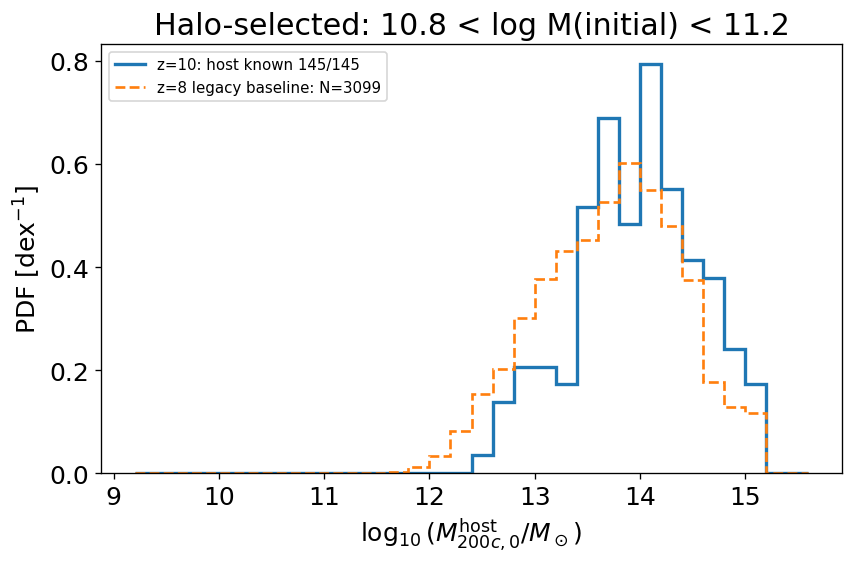

,Sample,N_host0,p16,median,p84
0,Halo M11,145,13.431891,14.007777,14.593455
1,Galaxy fiducial,57191,12.455200,13.466153,14.286966
2,Galaxy conservative,3,14.010675,14.129138,14.629807


In [9]:
q = samples['Halo M11']
fig,ax = plt.subplots(figsize=(7,4.6))
halo_pdf = pdf_table(q.logM200c_z0)
if q.logM200c_z0.notna().any():
    draw_pdf(ax, halo_pdf['PDF_dex^-1'], pdf_edges, lw=2, label=f'z=10: host known {q.logM200c_z0.notna().sum()}/{len(q)}')
else:
    ax.text(.5,.5,'No z=10 halo hosts recovered', transform=ax.transAxes, ha='center')
halo_pdf.to_csv(out_dir / 'halo_M11_z10_pdf.csv',index=False)
z8_csv = data_dir / 'tng300_z8_M11_descendants.csv'
if z8_csv.is_file():
    z8 = pd.read_csv(z8_csv)
    z8 = z8.loc[(z8.logM200c_z8 > logM_min) & (z8.logM200c_z8 < logM_max) & np.isfinite(z8.logM200c_z0)]
    if len(z8):
        # Independent full-range bins prevent an extreme z=8 tail from being clipped.
        e8 = np.arange(min(low,np.floor(z8.logM200c_z0.min()/PDF_BIN_WIDTH)*PDF_BIN_WIDTH),
                       max(high,np.ceil(z8.logM200c_z0.max()/PDF_BIN_WIDTH)*PDF_BIN_WIDTH+PDF_BIN_WIDTH)+PDF_BIN_WIDTH/2,
                       PDF_BIN_WIDTH)
        p8 = pdf_table(z8.logM200c_z0, e8)
        draw_pdf(ax, p8['PDF_dex^-1'],e8, lw=1.6, ls='--',label=f'z=8 legacy baseline: N={len(z8)}')
ax.set(xlabel=r'$\log_{10}(M_{200c,0}^{\rm host}/M_\odot)$', ylabel=r'PDF [dex$^{-1}$]',
       title=f'Halo-selected: {logM_min:g} < log M(initial) < {logM_max:g}')
handles,labels = ax.get_legend_handles_labels()
if handles: ax.legend(fontsize=9)
savefig(fig,'halo_M11_z10_vs_z8_pdf')
display(pd.DataFrame([{'Sample':label, 'N_host0':g.logM200c_z0.notna().sum(),
                      'p16':quantiles(g.logM200c_z0)[0], 'median':quantiles(g.logM200c_z0)[1],
                      'p84':quantiles(g.logM200c_z0)[2]} for label,g in samples.items()]))

## 8. Fig. 8 analogues: four epochs
左から z=8,5,1,0。淡い点が individual seed、黒線と縦 bars が mass bin の median / 16–84%。灰色領域は log M(initial)<10.8 の解像度注意領域。低質量を自動除外せず population の差を可視化する。

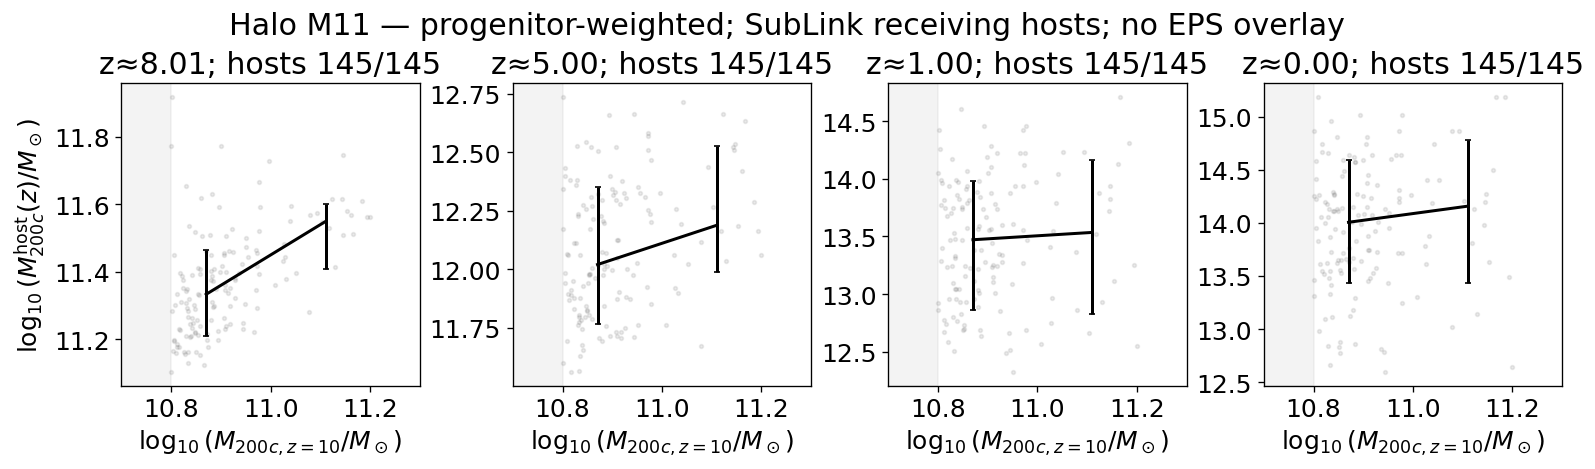

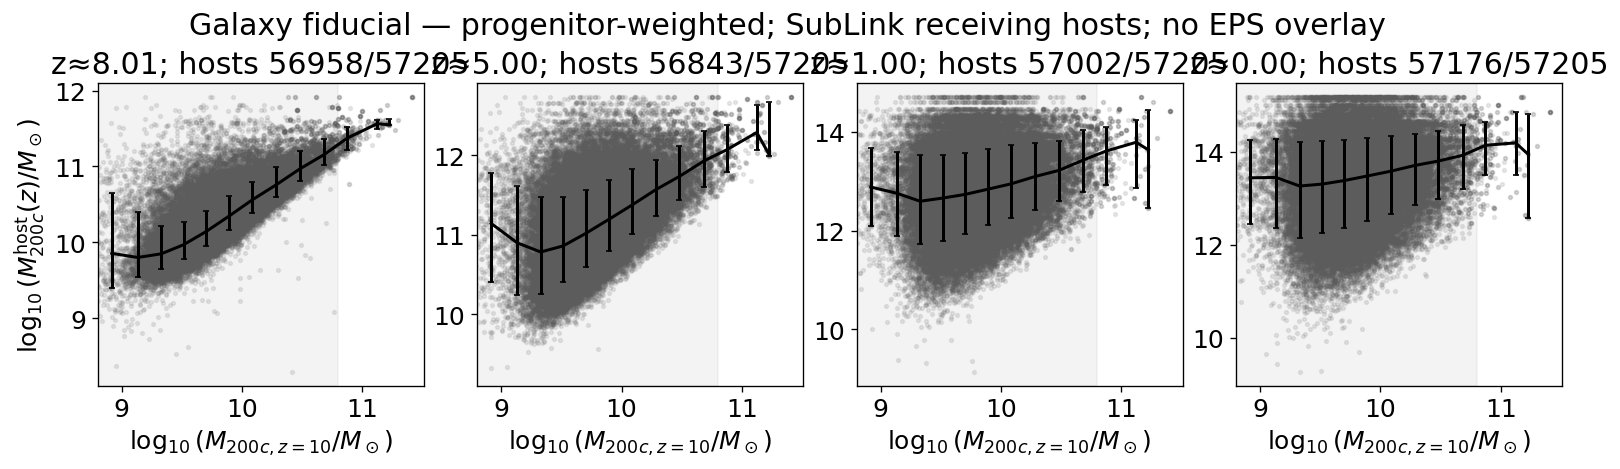

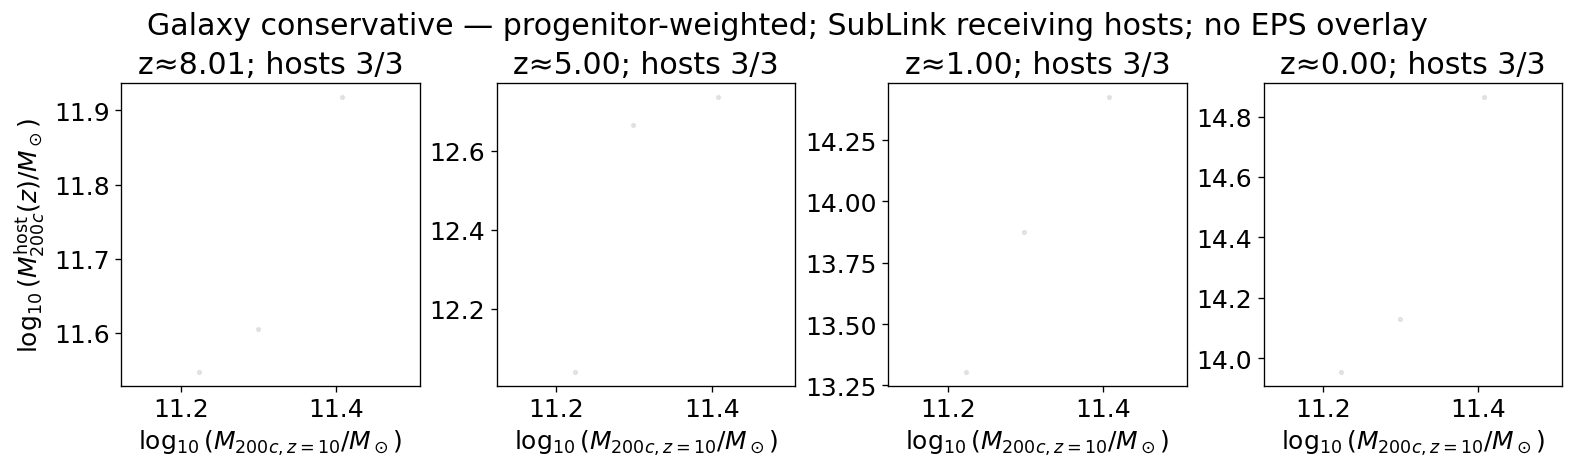

In [10]:
relation_tables = []
def plot_fig8(q, label, name):
    fig,axes = plt.subplots(1,4,figsize=(13,3.8),sharex=True)
    for ax,(z,s) in zip(axes,epochs.items()):
        ycol = f'logM200c_z{z}'
        v = q.loc[np.isfinite(q.logM200c_z10) & np.isfinite(q[ycol])]
        ax.scatter(v.logM200c_z10,v[ycol],s=5,alpha=.12,color='0.35',rasterized=True)
        tab = binned_relation(q,'logM200c_z10',ycol,initial_mass_edges)
        tab['Sample'],tab['Target_z'] = label,z
        relation_tables.append(tab)
        t = tab.loc[tab['plot']]
        if len(t):
            ax.errorbar(t.x,t['median'],yerr=[t['median']-t.p16,t.p84-t['median']],color='k',lw=1.8,capsize=2)
        ax.axvspan(initial_mass_edges[0],RELIABILITY_GUIDE_LOGM,color='0.5',alpha=.09)
        ax.set(title=f'z≈{float(headers[s]["Redshift"]):.2f}; hosts {len(v)}/{len(q)}',
               xlabel=r'$\log_{10}(M_{200c,z=10}/M_\odot)$')
        if len(q) and q.logM200c_z10.notna().any():
            ax.set_xlim(max(initial_mass_edges[0],q.logM200c_z10.min()-.1),q.logM200c_z10.max()+.1)
        if not len(v): ax.text(.5,.5,'No recovered hosts',transform=ax.transAxes,ha='center')
    axes[0].set_ylabel(r'$\log_{10}(M_{200c}^{\rm host}(z)/M_\odot)$')
    fig.suptitle(label + ' — progenitor-weighted; SubLink receiving hosts; no EPS overlay')
    savefig(fig,name)

plot_fig8(samples['Halo M11'],'Halo M11','fig8_halo_M11')
plot_fig8(samples['Galaxy fiducial'],'Galaxy fiducial','fig8_galaxy_fiducial')
plot_fig8(samples['Galaxy conservative'],'Galaxy conservative','fig8_galaxy_conservative')
pd.concat(relation_tables,ignore_index=True).to_csv(out_dir / 'fig8_binned_relations.csv',index=False)

## 9. Fig. 7 analogues: fractions, stellar masses and fate PDFs
Panel (a) の denominator は全 selected seeds（unresolved を含む）。Panel (b) は central/satellite proxy survivor のみ。Panel (c) は各 fate 内の host-known sample に条件づけた PDF。n_host/n_fate を表示し、open/filled circle と horizontal bar は median と 16–84%。

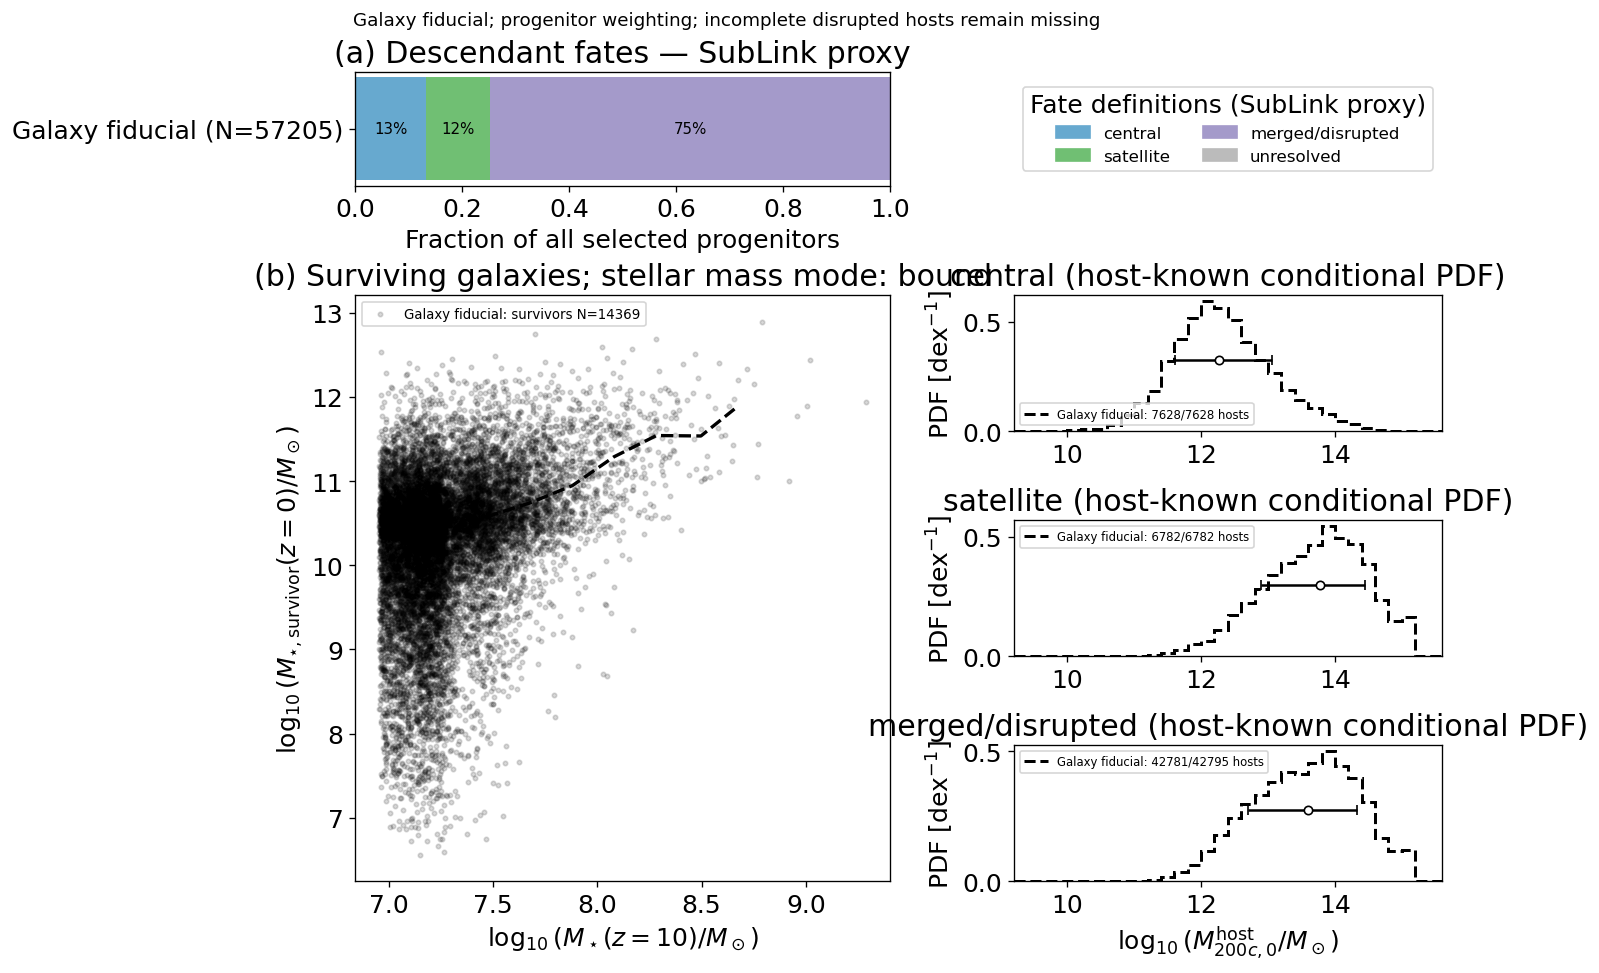

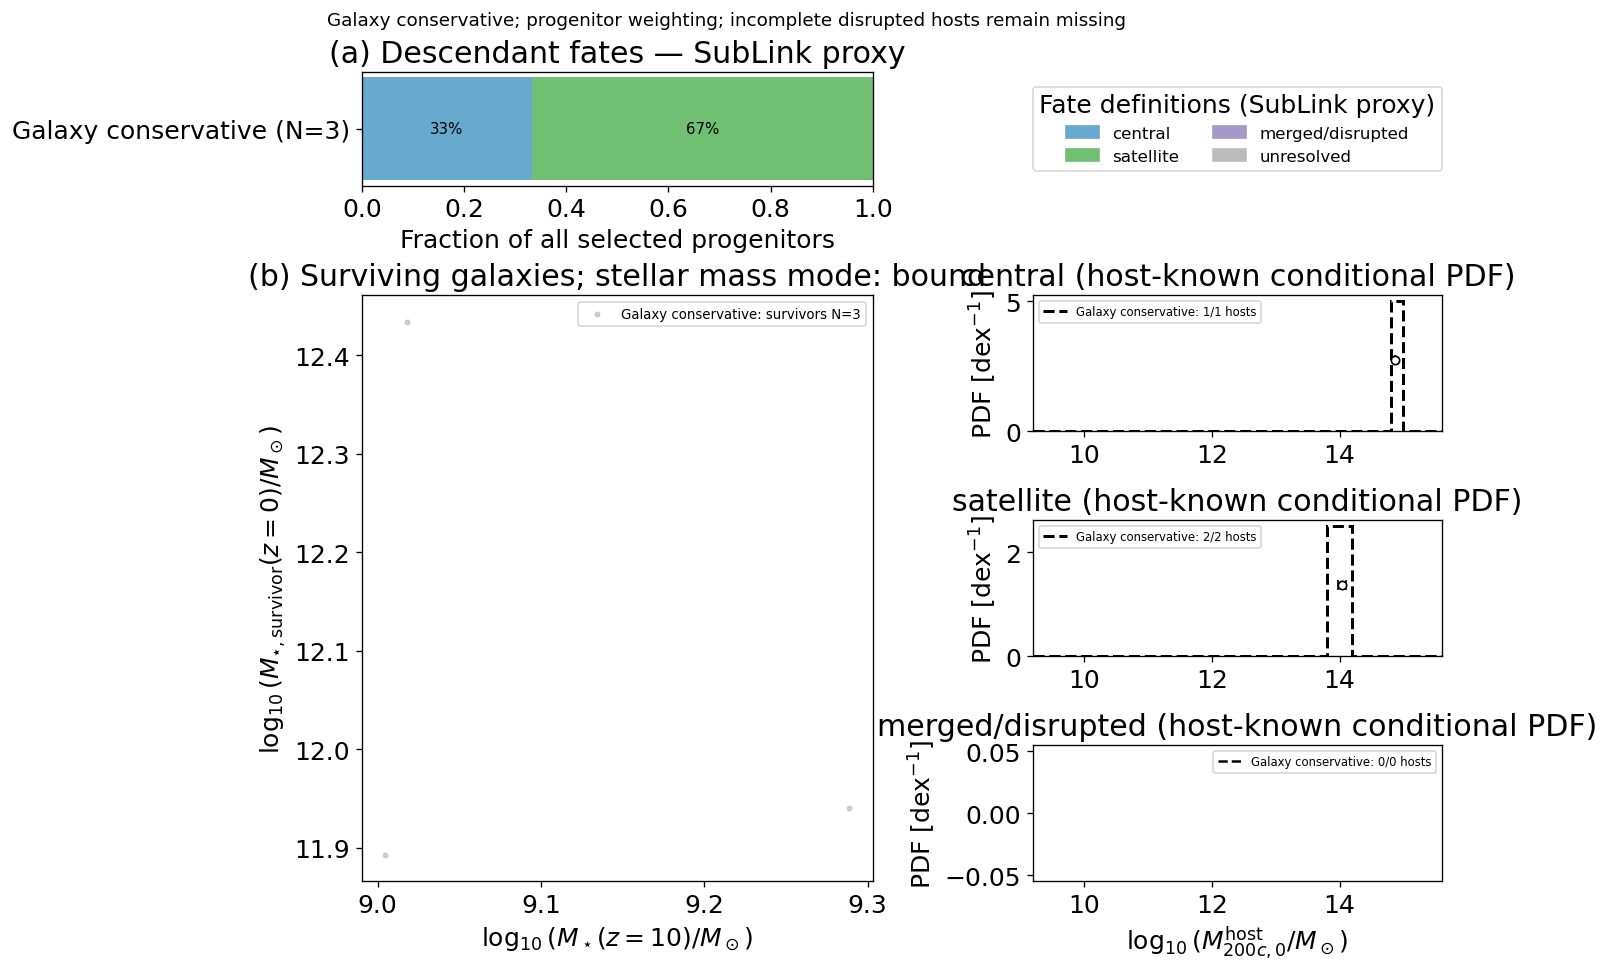

,Comparison,Sample,Fate,N,N_selected,Fraction,Wilson68_lo,Wilson68_hi
0,fig7_fiducial,Galaxy fiducial,central,7628,57205,0.133345,0.131930,0.134773
1,fig7_fiducial,Galaxy fiducial,satellite,6782,57205,0.118556,0.117211,0.119914
2,fig7_fiducial,Galaxy fiducial,merged/disrupted,42795,57205,0.748099,0.746280,0.749910
3,fig7_fiducial,Galaxy fiducial,unresolved,0,57205,0.000000,0.000000,0.000017
4,fig7_conservative,Galaxy conservative,central,1,3,0.333333,0.135643,0.614357
5,fig7_conservative,Galaxy conservative,satellite,2,3,0.666667,0.385643,0.864357
6,fig7_conservative,Galaxy conservative,merged/disrupted,0,3,0.000000,0.000000,0.250000
7,fig7_conservative,Galaxy conservative,unresolved,0,3,0.000000,0.000000,0.250000


In [11]:
fate_order = ['central','satellite','merged/disrupted','unresolved']
fate_colors = ['#67a9cf','#70bf73','#a49aca','#bbbbbb']
fate_rows, pdf_rows, stellar_relations = [], [], []
def plot_fig7(parent, bright, label, name):
    fig = plt.figure(figsize=(12,8))
    gs = fig.add_gridspec(4,2,width_ratios=[1.25,1],height_ratios=[1,1.2,1.2,1.2])
    axf = fig.add_subplot(gs[0,0])
    axlegend = fig.add_subplot(gs[0,1])
    axlegend.axis('off')
    axs = fig.add_subplot(gs[1:,0])
    axpdf = [fig.add_subplot(gs[j+1,1]) for j in range(3)]
    selected = [(label,parent,'black','--',False)]
    if bright is not None:
        selected.append(('UV-bright',bright,'#f29b16','-',True))
    for row,(lab,q,color,ls,filled) in enumerate(selected):
        left = 0
        for fate,fc in zip(fate_order,fate_colors):
            k = int((q.Fate == fate).sum())
            frac = k/len(q) if len(q) else 0
            axf.barh(row,frac,left=left,color=fc,height=.6)
            if frac > .045: axf.text(left+frac/2,row,f'{frac:.0%}',ha='center',va='center',fontsize=9)
            lo,hi = wilson(k,len(q))
            fate_rows.append({'Comparison':name,'Sample':lab,'Fate':fate,'N':k,'N_selected':len(q),
                              'Fraction':k/len(q) if len(q) else np.nan,'Wilson68_lo':lo,'Wilson68_hi':hi})
            left += frac
        v = q.loc[q.Fate.isin(['central','satellite']) & q.logMstar_z0.notna()]
        axs.scatter(v.logMstar_z10,v.logMstar_z0,s=11 if filled else 7,alpha=.6 if filled else .15,
                    color=color,label=f'{lab}: survivors N={len(v)}',rasterized=True)
        edges = np.arange(6.8,12.01,.2)
        t = binned_relation(v,'logMstar_z10','logMstar_z0',edges)
        t['Comparison'],t['Sample'] = name,lab
        stellar_relations.append(t)
        used = t.loc[t['plot']]
        axs.plot(used.x,used['median'],color=color,ls=ls,lw=2)
        for ax,fate in zip(axpdf,fate_order[:3]):
            g = q.loc[q.Fate == fate]
            values = g.logM200c_z0.dropna()
            tab = pdf_table(values)
            tab['Comparison'],tab['Sample'],tab['Fate'] = name,lab,fate
            tab['N_fate'],tab['N_host_known'] = len(g),len(values)
            pdf_rows.append(tab)
            if len(values):
                draw_pdf(ax, tab['PDF_dex^-1'],pdf_edges,color=color,ls=ls,lw=1.8,
                          label=f'{lab}: {len(values)}/{len(g)} hosts')
                p16,med,p84 = quantiles(values)
                peak = np.nanmax(tab['PDF_dex^-1'])
                y = peak * (.35 if filled else .55)
                ax.errorbar(med,y,xerr=[[med-p16],[p84-med]],fmt='o',color=color,
                            mfc=color if filled else 'white',capsize=3,ms=5)
            else:
                ax.plot([],[],color=color,ls=ls,label=f'{lab}: 0/{len(g)} hosts')
    axf.set(yticks=range(len(selected)),yticklabels=[s[0]+f' (N={len(s[1])})' for s in selected],
            xlim=(0,1),xlabel='Fraction of all selected progenitors',title='(a) Descendant fates — SubLink proxy')
    axf.invert_yaxis()
    from matplotlib.patches import Patch
    axlegend.legend(handles=[Patch(color=c,label=f) for f,c in zip(fate_order,fate_colors)],
                    loc='center',ncol=2,fontsize=10,title='Fate definitions (SubLink proxy)')
    axs.set(xlabel=r'$\log_{10}(M_\star(z=10)/M_\odot)$',ylabel=r'$\log_{10}(M_{\star,\rm survivor}(z=0)/M_\odot)$',
            title=f'(b) Surviving galaxies; stellar mass mode: {STELLAR_MASS_MODE}')
    axs.legend(fontsize=8)
    for ax,fate in zip(axpdf,fate_order[:3]):
        ax.set(title=fate+' (host-known conditional PDF)',ylabel=r'PDF [dex$^{-1}$]',xlim=(pdf_edges[0],pdf_edges[-1]))
        ax.legend(fontsize=7)
    axpdf[-1].set_xlabel(r'$\log_{10}(M_{200c,0}^{\rm host}/M_\odot)$')
    fig.suptitle(label+'; progenitor weighting; incomplete disrupted hosts remain missing',fontsize=11)
    savefig(fig,name)

for flag,label,name in [('GalaxyFiducial','Galaxy fiducial','fig7_fiducial'),
                        ('GalaxyConservative','Galaxy conservative','fig7_conservative')]:
    parent = tracked.loc[tracked[flag]]
    bright = parent.loc[parent.UVBright] if uv_info['available'] else None
    plot_fig7(parent,bright,label,name)
    if uv_info['available'] and not parent.UVKnown.all():
        plot_fig7(parent.loc[parent.UVKnown],bright,label+' (UV-known parent)',name+'_uv_known_parent')
pd.DataFrame(fate_rows).to_csv(out_dir / 'fig7_fate_fractions.csv',index=False)
pd.concat(pdf_rows,ignore_index=True).to_csv(out_dir / 'fig7_host_mass_pdfs.csv',index=False)
pd.concat(stellar_relations,ignore_index=True).to_csv(out_dir / 'fig7_stellar_relations.csv',index=False)
display(pd.DataFrame(fate_rows))

## 10. Resolution sensitivity and duplicate descendants
低い nominal stellar cut と保守的な cut の PDF／fate の差を可視化。これは収束テストの代わりではない。TNG100 と比較する場合は同一 mass definition・stellar aperture・tree definition・selection を用い、volume差も考慮する。

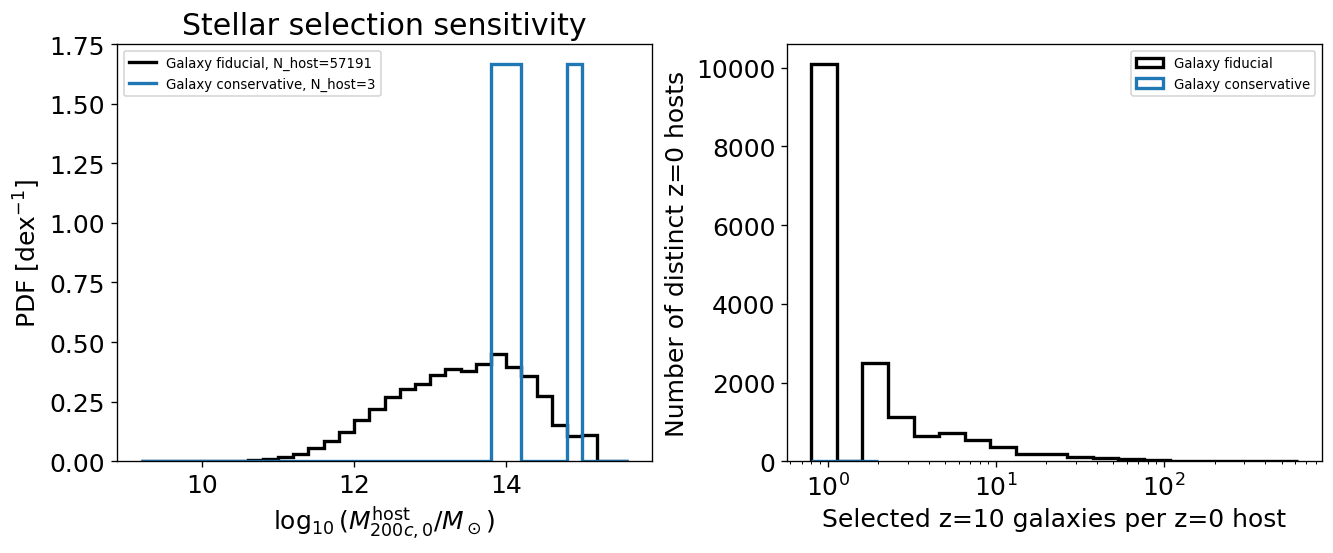

In [12]:
fig,axes = plt.subplots(1,2,figsize=(11,4.5))
for label,color in [('Galaxy fiducial','black'),('Galaxy conservative','tab:blue')]:
    q = samples[label]
    p = pdf_table(q.logM200c_z0)
    if q.logM200c_z0.notna().any():
        draw_pdf(axes[0], p['PDF_dex^-1'],pdf_edges,color=color,lw=2,label=f'{label}, N_host={q.logM200c_z0.notna().sum()}')
    known = q.loc[q.logM200c_z0.notna()]
    mult = known.groupby('GroupID_z0').size()
    if len(mult):
        axes[1].hist(mult,bins=np.geomspace(.8,max(2,mult.max()+1),20),histtype='step',lw=2,color=color,label=label)
axes[0].set(xlabel=r'$\log_{10}(M_{200c,0}^{\rm host}/M_\odot)$',ylabel=r'PDF [dex$^{-1}$]',title='Stellar selection sensitivity')
axes[1].set(xlabel='Selected z=10 galaxies per z=0 host',ylabel='Number of distinct z=0 hosts',xscale='log')
for ax in axes:
    if ax.get_legend_handles_labels()[0]: ax.legend(fontsize=8)
savefig(fig,'stellar_cut_sensitivity_and_host_multiplicity')

## 11. Save provenance and final checks
結果は `protohalo/data/tng300_z10_colibre/`。Figures は PNG / SVG、bin summaries と PDFs と full tracking table は CSV。実行環境・selection・UV provenance・欠損率も JSON に保存。

In [13]:
for flag in ['HaloSelected','GalaxyFiducial','GalaxyConservative']:
    q = tracked.loc[tracked[flag]]
    assert sum((q.Fate == f).sum() for f in fate_order) == len(q)
assert not tracked.SubhaloID_z10.duplicated().any()
assert not tracked.loc[tracked.Fate.isin(['central','satellite']),'SubhaloID_z0'].duplicated().any(), 'Survivor identity collision'
assert tracked.loc[tracked.Fate.isin(['central','satellite']),'MainIdentity_snap99'].all()
meta = {
    'simulation':'TNG300-1','basePath':str(basePath),'h':h,'start_snapshot':4,
    'actual_redshifts':{str(s):float(v['Redshift']) for s,v in headers.items()},
    'target_snapshots':epochs,'halo_logmass_cut':[logM_min,logM_max],
    'stellar_cuts_Msun':[MSTAR_FIDUCIAL,MSTAR_CONSERVATIVE],
    'stellar_mass_mode':STELLAR_MASS_MODE,'require_subhalo_flag':REQUIRE_SUBHALO_FLAG,
    'tracking_cache_version':TRACKER_CACHE_VERSION,
    'tracking_cache_directory':str(TRACK_CACHE_DIR),
    'tracking_block_rows':TRACK_BLOCK_ROWS,'tracking_memory_MB':TRACK_MEMORY_MB,
    'tree':TREE_NAME,'survival_definition':'FirstProgenitor identity on EVERY forward edge; proxy for HBT survival',
    'weighting':'one entry per z=10 progenitor; no descendant deduplication',
    'pdf_normalization':'conditional on finite host mass WITHIN each fate/sample; per dex',
    'uv':uv_info,'disrupted_host_provenance':DISRUPTED_HOST_PROVENANCE,
    'min_relation_bin_N':MIN_BIN_N,'pdf_bin_width_dex':PDF_BIN_WIDTH,
    'completeness':completeness.to_dict(orient='records'),
    'limitations':['SubLink proxy is not HBT-HERONS persistent TrackID survival',
                   'Terminated tracks lack z=0 hosts unless independently supplied',
                   'Nominal COLIBRE stellar cut is below one initial TNG300 baryon mass element',
                   'Bound stellar mass is not COLIBRE 50 pkpc aperture mass',
                   'Legacy z=8 table uses a different tracking implementation',
                   'No EPS or digitized COLIBRE curves; no convergence claim'],
}
(out_dir / 'analysis_metadata.json').write_text(json.dumps(meta,indent=2,ensure_ascii=False))
print('Saved outputs:',out_dir)
print('UV comparison:', 'available' if uv_info['available'] else 'not available (genuine attenuated UV catalog required)')
print('Review host_coverage_by_fate.csv before interpreting merged/disrupted PDFs.')
if not samples['Galaxy conservative'].shape[0]:
    print('Conservative selection is empty; its figures intentionally contain no estimated distributions.')
if tracked.Fate.eq('unresolved').any():
    print('Unresolved seeds remain in fraction denominators; inspect TrackingStatus.')

Saved outputs: /home/tnguser/tng-work/protohalo/data/tng300_z10_colibre
UV comparison: not available (genuine attenuated UV catalog required)
Review host_coverage_by_fate.csv before interpreting merged/disrupted PDFs.


## 12. Simple attenuated-UV proxy from SFR — no tree rerun

**このセクションの3 code cellsだけ実行可能**。既存 descendant CSV と metadata を読み、snapshot 4 の `SubhaloSFR` だけを追加する。最初はcatalogの1 fieldを読む必要があるが、seedごとのSFRを `protohalo/cache/uv_sfr_proxy_cache/` に保存するので、以後は再読込しない。既存の真の UV catalog や前のFig. 7結果は上書きしない。

Chabrier IMF向けの近似換算として [Madau & Dickinson (2014), §3.1.1](https://ned.ipac.caltech.edu/level5/March14/Madau/Madau3.html) の Salpeter coefficient と IMF換算を用いる：
$$K_{\rm UV}=1.15\times10^{-28}\times0.63=7.245\times10^{-29},\qquad L_\nu=\mathrm{SFR}/K_{\rm UV}.$$
$L_\nu$ は erg s$^{-1}$ Hz$^{-1}$、SFR は $M_\odot$ yr$^{-1}$。
$$M_{\rm UV,int}^{\rm proxy}=51.595-2.5\log_{10} L_\nu\simeq -18.76-2.5\log_{10}\mathrm{SFR},$$
$$M_{\rm UV,attn}^{\rm proxy}=M_{\rm UV,int}^{\rm proxy}+A_{1500}.$$

**$A_{1500}=0.5$ mag は測定値でもz=10の較正値でもなく、探索用の一様screen仮定**。0,0.5,1.0 magでselection sensitivityを出す。一定の減光ではUV selectionはSFR cutと等価で、独立したUV observableではない。Lnu換算は定常に近い星形成を想定する一方、`SubhaloSFR` は瞬間的なgas SFR。若い／burst後のgalaxy、非太陽金属量、dust geometry、視線依存性は再現しない。SFR=0はproxy luminosity=0（magnitude=+infinity）として既知のfaint objectに数えるが、実際には残存する若い星のUVがありうる。

図・列名には **SFR UV proxy** と明記。PDF はhost判明objectに条件づけ、particle count diagnosticsも出す。fiducialはそのまま。比較用parentを **実際の星粒子が5個以上**（`GFM_StellarFormationTime > 0`）に変更して別のFig. 7 analogueを作る。`SubhaloLenType[:,4]` はwindを含むため候補抽出だけに使い、候補のformation timeを読む。後者も収束済みsampleと主張しない。数値・図は `data/tng300_z10_colibre/uv_sfr_proxy/` に別保存する。

星粒子数はbound subhaloの全半径で数える。元のfiducial内で比較するため、従来のfiducial mass cutは引き続き適用される。固定のstellar mass下限は追加しない。図のtitleに、5個以上のparentで観測された最小 $M_\star(z=10)$ を表示する。この値は粒子数選択の結果であり、同値なmass thresholdではない。星粒子の質量は一定でないため、5個×nominal baryon massでは置き換えない。空sampleの最小質量は未定義と明記する。

初回はsnapshot 4のstar formation timeとoffsetsが必要。粒子数を `protohalo/cache/star_particle_count_cache/` に50個ごと／10秒経過後に逐次保存し、Interrupt後も再開可能。SFR cacheとmerger-tree結果は再利用する。改訂前のmass-selected図・CSVは再実行するまで旧結果のままなので、末尾3 code cellsを再実行する。

In [ ]:
# Standalone appendix parameters. These 3 cells do not run PointerTracker.
from pathlib import Path
import os
UV_PROXY_A1500 = 0.5
UV_PROXY_A_GRID = [0.0, 0.5, 1.0]
UV_PROXY_K = 1.15e-28 * 0.63  # SFR [Msun/yr] = K * Lnu [erg/s/Hz]; Chabrier rescaling
UV_PROXY_MAG_CUT = -18.0
UV_PROXY_MIN_STARS = 5  # formed, bound star particles; excludes wind-phase PartType4
UV_PROXY_MIN_BIN_N = 10
UV_PROXY_INPUT_CSV = None  # optional explicit path to tng300_z10_descendants.csv
UV_PROXY_BASE_PATH = None  # optional TNG300-1/output override; otherwise use metadata or TNG_OUTPUT_DIR
UV_PROXY_CACHE_DIR = None  # optional override; default: protohalo/cache/uv_sfr_proxy_cache

In [ ]:
import json, glob, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import illustris_python as il

cwd_proxy = Path.cwd().resolve()
proxy_root = next((r/'protohalo' for r in [cwd_proxy,*cwd_proxy.parents]
                   if (r/'protohalo'/'notebooks').is_dir()), None)
if proxy_root is None:
    proxy_root = cwd_proxy.parent if cwd_proxy.name == 'notebooks' else cwd_proxy
proxy_output = Path(os.environ.get('TNG_ANALYSIS_DIR', str(proxy_root/'data'/'tng300_z10_colibre'))).expanduser()
proxy_csv = Path(UV_PROXY_INPUT_CSV).expanduser() if UV_PROXY_INPUT_CSV else proxy_output/'tng300_z10_descendants.csv'
proxy_meta_path = proxy_csv.with_name('analysis_metadata.json')
if not proxy_csv.is_file() or not proxy_meta_path.is_file():
    raise FileNotFoundError('Run the descendant analysis first, or set UV_PROXY_INPUT_CSV (with analysis_metadata.json alongside).')
proxy_input_meta = json.loads(proxy_meta_path.read_text())
if proxy_input_meta.get('simulation') != 'TNG300-1' or proxy_input_meta.get('start_snapshot') != 4:
    raise ValueError('UV proxy requires the TNG300-1 snapshot-4 descendant table.')
proxy_frame = pd.read_csv(proxy_csv)
proxy_required = {'SubhaloID_z10','GalaxyFiducial','Mstar_z10','logMstar_z10','Npart4_z10',
                  'Fate','M200c_z0','logM200c_z0','logMstar_z0'}
if not proxy_required.issubset(proxy_frame.columns) or proxy_frame.SubhaloID_z10.duplicated().any():
    raise ValueError('Invalid descendant-table columns or duplicate IDs')
proxy_ids_raw = pd.to_numeric(proxy_frame.SubhaloID_z10,errors='raise')
if proxy_ids_raw.isna().any() or (proxy_ids_raw < 0).any() or (proxy_ids_raw % 1 != 0).any():
    raise ValueError('Invalid seed IDs')
proxy_ids = proxy_ids_raw.to_numpy(dtype=np.int64)
proxy_base = Path(UV_PROXY_BASE_PATH or os.environ.get('TNG_OUTPUT_DIR') or proxy_input_meta['basePath']).expanduser().resolve()
proxy_cache_dir = Path(UV_PROXY_CACHE_DIR).expanduser() if UV_PROXY_CACHE_DIR else proxy_root/'cache'/'uv_sfr_proxy_cache'
proxy_result_dir = proxy_csv.parent/'uv_sfr_proxy'
proxy_cache_dir.mkdir(parents=True,exist_ok=True)
proxy_result_dir.mkdir(parents=True,exist_ok=True)

if not np.isfinite(UV_PROXY_K) or UV_PROXY_K <= 0 or UV_PROXY_MIN_BIN_N < 1:
    raise ValueError('Positive finite UV coefficient and minimum-bin N required')
proxy_a_values = np.unique(np.asarray([*UV_PROXY_A_GRID,UV_PROXY_A1500],dtype=float))
if not np.isfinite(proxy_a_values).all() or (proxy_a_values < 0).any():
    raise ValueError('Attenuation values must be finite and nonnegative')
if not np.isfinite(UV_PROXY_MAG_CUT) or not isinstance(UV_PROXY_MIN_STARS, (int, np.integer)) or UV_PROXY_MIN_STARS < 1:
    raise ValueError('Invalid magnitude or minimum formed-star count')
# Fingerprint catalogs and row order. Replacing the catalog invalidates the SFR-only cache.
proxy_gc0 = Path(il.groupcat.gcPath(str(proxy_base),4,0))
proxy_paths = sorted(glob.glob(str(proxy_gc0.parent/'*.hdf5')))
if not proxy_paths:
    raise FileNotFoundError(f'No snapshot-4 group catalogs under {proxy_gc0.parent}')
proxy_stats = [[str(Path(f).resolve()),Path(f).stat().st_size,Path(f).stat().st_mtime_ns] for f in proxy_paths]
proxy_sig_data = {'version':'subhalo-sfr-v1','base':str(proxy_base),'snapshot':4,
                  'files':proxy_stats,'ids_sha256':hashlib.sha256(proxy_ids.tobytes()).hexdigest()}
proxy_sig = hashlib.sha256(json.dumps(proxy_sig_data,sort_keys=True).encode()).hexdigest()
proxy_cache_file = proxy_cache_dir/f'sfr_z10_{proxy_sig[:20]}.npz'
if proxy_cache_file.is_file():
    with np.load(proxy_cache_file,allow_pickle=False) as z:
        if str(z['signature'].item()) != proxy_sig or not np.array_equal(z['seed_ids'],proxy_ids):
            raise ValueError('SFR cache mismatch')
        proxy_sfr = z['sfr'].copy()
    print('Loaded SFR checkpoint:',proxy_cache_file)
else:
    print('Loading only snapshot-4 SubhaloSFR; no tree reads.')
    proxy_header = il.groupcat.loadHeader(str(proxy_base),4)
    if abs(float(proxy_header['Redshift']) - 10) > .15:
        raise ValueError('Wrong redshift for SFR catalog')
    all_sfr_proxy = np.asarray(il.groupcat.loadSubhalos(str(proxy_base),4,fields=['SubhaloSFR']),dtype=float)
    if len(proxy_ids) and proxy_ids.max() >= len(all_sfr_proxy):
        raise IndexError('Seed ID exceeds the SFR catalog')
    proxy_sfr = all_sfr_proxy[proxy_ids].copy()
    del all_sfr_proxy
    if np.any(np.isfinite(proxy_sfr) & (proxy_sfr < 0)) or np.isinf(proxy_sfr).any():
        raise ValueError('Negative or infinite SFR in catalog')
    proxy_cache_tmp = proxy_cache_file.with_suffix('.tmp')
    with proxy_cache_tmp.open('wb') as f:
        np.savez_compressed(f,signature=np.array(proxy_sig),seed_ids=proxy_ids,sfr=proxy_sfr)
    proxy_cache_tmp.replace(proxy_cache_file)
if proxy_sfr.shape != proxy_ids.shape or np.any(np.isfinite(proxy_sfr) & (proxy_sfr < 0)) or np.isinf(proxy_sfr).any():
    raise ValueError('Invalid cached SFR values/shape')

# Rest-frame AB absolute magnitude from luminosity at a distance of 10 pc.
UV_PROXY_AB_CONSTANT = 2.5*np.log10(4*np.pi*(10*3.0856775814913673e18)**2)-48.60
proxy_m0 = UV_PROXY_AB_CONSTANT + 2.5*np.log10(UV_PROXY_K)
def sfr_to_uv_proxy(sfr, attenuation=0.0):
    sfr = np.asarray(sfr,dtype=float)
    if np.any(np.isfinite(sfr) & (sfr < 0)) or np.isinf(sfr).any():
        raise ValueError('Negative/infinite SFR')
    attenuation = float(attenuation)
    if not np.isfinite(attenuation) or attenuation < 0:
        raise ValueError('Invalid attenuation')
    mag = np.full(sfr.shape,np.nan)
    mag[np.isfinite(sfr) & (sfr == 0)] = np.inf
    positive = np.isfinite(sfr) & (sfr > 0)
    mag[positive] = proxy_m0 - 2.5*np.log10(sfr[positive]) + attenuation
    return mag

proxy_frame['SFR_z10'] = proxy_sfr
proxy_frame['UV_SFR_ProxyKnown'] = np.isfinite(proxy_sfr)
proxy_frame['MUV_int_SFR_proxy'] = sfr_to_uv_proxy(proxy_sfr)
proxy_frame['MUV_attn_SFR_proxy'] = sfr_to_uv_proxy(proxy_sfr,UV_PROXY_A1500)
proxy_frame['UVBright_SFR_proxy'] = (proxy_frame.GalaxyFiducial & proxy_frame.UV_SFR_ProxyKnown
                                   & (proxy_frame.MUV_attn_SFR_proxy < UV_PROXY_MAG_CUT))

# Count actual stars only where the total PartType4 count could pass the cut.
# SubhaloLenType[:,4] alone includes winds and is only an upper bound on Nstar.
import sqlite3, time
from contextlib import closing
from tqdm.auto import tqdm
star_snap0 = Path(il.snapshot.snapPath(str(proxy_base),4,0))
star_files = sorted(glob.glob(str(star_snap0.parent/'*.hdf5')))
if not star_files:
    raise FileNotFoundError(f'No snapshot-4 particle files under {star_snap0.parent}; exact star counts require them.')
star_input_paths = [*star_files,il.groupcat.offsetPath(str(proxy_base),4)]
star_input_stats = [[str(Path(f).resolve()),Path(f).stat().st_size,Path(f).stat().st_mtime_ns] for f in star_input_paths]
star_signature_data = {'version':'formed-bound-stars-v1','base':str(proxy_base),'snapshot':4,
                       'criterion':'GFM_StellarFormationTime > 0',
                       'group_catalogs':proxy_stats,'snapshot_and_offsets':star_input_stats}
star_signature = hashlib.sha256(json.dumps(star_signature_data,sort_keys=True).encode()).hexdigest()
star_cache_dir = proxy_root/'cache'/'star_particle_count_cache'
star_cache_dir.mkdir(parents=True,exist_ok=True)
star_cache_path = star_cache_dir/f'nstar_z10_{star_signature[:20]}.sqlite3'
particle_counts = pd.to_numeric(proxy_frame.Npart4_z10,errors='raise')
if particle_counts.isna().any() or (particle_counts < 0).any() or (particle_counts % 1 != 0).any():
    raise ValueError('Invalid PartType4 particle count')
star_candidate_mask = proxy_frame.GalaxyFiducial & particle_counts.ge(UV_PROXY_MIN_STARS)
star_candidates = proxy_frame.loc[star_candidate_mask,'SubhaloID_z10'].astype(np.int64).to_numpy()
star_expected_n4 = dict(zip(proxy_ids,particle_counts.astype(np.int64)))
with closing(sqlite3.connect(str(star_cache_path),timeout=60)) as star_conn:
    star_conn.execute('PRAGMA journal_mode=WAL')
    star_conn.execute('PRAGMA synchronous=FULL')
    star_conn.execute('CREATE TABLE IF NOT EXISTS metadata (signature TEXT PRIMARY KEY)')
    previous = star_conn.execute('SELECT signature FROM metadata').fetchone()
    if previous is not None and previous[0] != star_signature:
        raise ValueError('Star-count cache signature mismatch')
    star_conn.execute('INSERT OR IGNORE INTO metadata VALUES (?)',(star_signature,))
    star_conn.execute('CREATE TABLE IF NOT EXISTS counts (sid INTEGER PRIMARY KEY, nstar INTEGER NOT NULL)')
    star_conn.commit()
    star_count_map = dict(star_conn.execute('SELECT sid,nstar FROM counts'))
    star_pending = [int(sid) for sid in star_candidates if int(sid) not in star_count_map]
    print(f'Exact star-count cache: {len(star_candidates)-len(star_pending):,}/{len(star_candidates):,}; remaining {len(star_pending):,}')
    last_commit, batch = time.monotonic(), 0
    try:
        for sid in tqdm(star_pending,desc='Count formed stars (exclude winds)'):
            formation = il.snapshot.loadSubhalo(str(proxy_base),4,sid,'stars',fields=['GFM_StellarFormationTime'])
            if isinstance(formation,dict):
                if formation.get('count') == 0:
                    formation = np.empty(0)
                else:
                    formation = formation['GFM_StellarFormationTime']
            formation = np.asarray(formation)
            expected_n4 = int(star_expected_n4[sid])
            if formation.ndim != 1 or len(formation) != expected_n4 or not np.isfinite(formation).all():
                raise ValueError(f'Particle/catalog consistency failure for seed {sid}')
            count = int(np.count_nonzero(formation > 0))
            star_conn.execute('INSERT OR REPLACE INTO counts VALUES (?,?)',(sid,count))
            star_count_map[sid] = count
            batch += 1
            if batch >= 50 or time.monotonic()-last_commit >= 10:
                star_conn.commit();batch=0;last_commit=time.monotonic()
    finally:
        # Preserve completed counts on normal Interrupt; technical errors remain uncached.
        star_conn.commit()
proxy_frame['Nstar_formed_z10'] = proxy_frame.SubhaloID_z10.map(star_count_map)
# Counts below the PartType4 prefilter may remain unknown; they cannot pass regardless.
if proxy_frame.loc[star_candidate_mask,'Nstar_formed_z10'].isna().any():
    raise ValueError('Missing exact star count for an eligible seed')
known_count = proxy_frame.Nstar_formed_z10.notna()
if ((proxy_frame.loc[known_count,'Nstar_formed_z10'] < 0) |
    (proxy_frame.loc[known_count,'Nstar_formed_z10'] > particle_counts[known_count])).any():
    raise ValueError('Invalid cached star count')
proxy_frame['GalaxyAtLeastFiveStars'] = (proxy_frame.GalaxyFiducial & star_candidate_mask
                                        & proxy_frame.Nstar_formed_z10.ge(UV_PROXY_MIN_STARS))
star_parent = proxy_frame.loc[proxy_frame.GalaxyAtLeastFiveStars]
star_parent_min_mstar = float(star_parent.Mstar_z10.min()) if len(star_parent) else None
star_parent_label = f'Nstar >= {UV_PROXY_MIN_STARS}'
star_parent_mass_label = (f'observed min Mstar(z=10) = {star_parent_min_mstar:.4e} Msun'
                          if star_parent_min_mstar is not None else 'no selected galaxies; minimum Mstar undefined')
print(f'{star_parent_label}: N={len(star_parent):,}; {star_parent_mass_label}')

proxy_frame.to_csv(proxy_result_dir/'descendants_with_uv_sfr_proxy.csv',index=False)

proxy_fate_order = ['central','satellite','merged/disrupted','unresolved']
proxy_summary_rows = []
proxy_fate_rows = []
proxy_pdf_rows = []
proxy_parent_masks = {
    'Fiducial':proxy_frame.GalaxyFiducial,
    star_parent_label:proxy_frame.GalaxyAtLeastFiveStars,
}
for pname,pmask in proxy_parent_masks.items():
    parent = proxy_frame.loc[pmask]
    for a in proxy_a_values:
        mags = sfr_to_uv_proxy(parent.SFR_z10,a)
        bright = parent.loc[parent.UV_SFR_ProxyKnown & (mags < UV_PROXY_MAG_CUT)]
        vals = bright.logM200c_z0.dropna().to_numpy()
        p16,med,p84 = np.percentile(vals,[16,50,84]) if len(vals) else [np.nan]*3
        threshold = 10**((proxy_m0+a-UV_PROXY_MAG_CUT)/2.5)
        proxy_summary_rows.append({'Parent':pname,'A1500_mag':a,'SFR_cut_Msun_yr':threshold,
            'N_parent':len(parent),'Parent_min_Mstar_Msun':parent.Mstar_z10.min(),
            'UV_bright_min_Mstar_Msun':bright.Mstar_z10.min(),'N_SFR_known':int(parent.UV_SFR_ProxyKnown.sum()),'N_UV_proxy_bright':len(bright),
            'Bright_fraction_all_parent':len(bright)/len(parent) if len(parent) else np.nan,
            'N_host0_known':len(vals),'logMhost0_p16':p16,'logMhost0_median':med,'logMhost0_p84':p84,
            'Npart4_median':bright.Npart4_z10.median(),
            'Npart4_le2_fraction':bright.Npart4_z10.le(2).mean()})
        for fate in proxy_fate_order:
            k=int(bright.Fate.eq(fate).sum())
            proxy_fate_rows.append({'Parent':pname,'A1500_mag':a,'Fate':fate,'N':k,'N_selected':len(bright),
                                   'Fraction':k/len(bright) if len(bright) else np.nan})
proxy_summary = pd.DataFrame(proxy_summary_rows)
proxy_summary.to_csv(proxy_result_dir/'attenuation_sensitivity.csv',index=False)
pd.DataFrame(proxy_fate_rows).to_csv(proxy_result_dir/'uv_proxy_fate_fractions.csv',index=False)
display(proxy_summary)
proxy_metadata = {'model':'instantaneous SubhaloSFR to rest-frame 1500A AB magnitude + constant attenuation',
    'is_radiative_transfer_photometry':False,'simulation':'TNG300-1','snapshot':4,'KUV':UV_PROXY_K,
    'KUV_units':'Msun yr^-1 / (erg s^-1 Hz^-1)','AB_luminosity_constant':UV_PROXY_AB_CONSTANT,
    'reference':'https://ned.ipac.caltech.edu/level5/March14/Madau/Madau3.html',
    'fiducial_A1500_mag':UV_PROXY_A1500,'A1500_grid_mag':proxy_a_values.tolist(),
    'dust_model':'assumed constant screen, not calibrated/measured z=10 attenuation',
    'magnitude_cut':UV_PROXY_MAG_CUT,'stellar_mass_mode':proxy_input_meta['stellar_mass_mode'],
    'input_descendant_table':str(proxy_csv),'SFR_cache_signature':proxy_sig_data,
    'comparison_selection':{'min_formed_stars':int(UV_PROXY_MIN_STARS),
        'within_original_fiducial':True,'particle_membership':'bound subhalo, all radii; no 50pkpc count aperture',
        'criterion':'GFM_StellarFormationTime > 0','N_selected':len(star_parent),
        'observed_min_Mstar_Msun':star_parent_min_mstar,'star_count_cache':str(star_cache_path),
        'star_count_signature':star_signature_data},
    'limitations':['Instantaneous SFR rather than UV-timescale SFH average',
                   'No age, metallicity, viewing-angle or galaxy-dependent dust effects',
                   'At constant attenuation the UV proxy threshold is exactly an SFR threshold',
                   'SFR=0 means proxy-faint, not proof of no real UV emission',
                   'Galaxy survival remains a SubLink main-progenitor proxy'],
    'summaries':json.loads(proxy_summary.to_json(orient='records'))}
(proxy_result_dir/'uv_proxy_metadata.json').write_text(json.dumps(proxy_metadata,indent=2,ensure_ascii=False))
print('Approximate UV relation: M_int =',round(proxy_m0,3),'- 2.5 log10(SFR)')
print('Proxy products:',proxy_result_dir)

In [ ]:
# All plots are separate from the original figures; no PointerTracker calls or global changes.
from matplotlib.patches import Patch

def proxy_save(fig,name):
    fig.savefig(proxy_result_dir/f'{name}.png',dpi=180,bbox_inches='tight')
    fig.savefig(proxy_result_dir/f'{name}.svg',bbox_inches='tight')
    plt.show()

proxy_finite_hosts=proxy_frame.logM200c_z0.dropna().to_numpy()
proxy_low=min(10.,np.floor(proxy_finite_hosts.min()*5)/5) if len(proxy_finite_hosts) else 10.
proxy_high=max(15.6,np.ceil(proxy_finite_hosts.max()*5)/5+.2) if len(proxy_finite_hosts) else 15.6
proxy_edges=np.arange(proxy_low,proxy_high+.1,.2)
def proxy_pdf(values,ax,color,label,ls='-'):
    values=np.asarray(values,dtype=float)
    values=values[np.isfinite(values)]
    counts,_=np.histogram(values,bins=proxy_edges)
    if counts.sum()!=len(values):raise ValueError('PDF clips host masses')
    density=counts/(len(values)*np.diff(proxy_edges)) if len(values) else np.full(len(counts),np.nan)
    if len(values):
        assert np.isclose(np.sum(density*np.diff(proxy_edges)),1)
        ax.step(proxy_edges,np.r_[density,density[-1]],where='post',color=color,ls=ls,lw=1.6,label=label)
        p16,med,p84=np.percentile(values,[16,50,84])
        y=np.max(density)*(.35 if color!='black' else .55)
        ax.errorbar(med,y,xerr=[[med-p16],[p84-med]],fmt='o',color=color,
                    mfc='white' if color=='black' else color,capsize=2,ms=4)
    else:ax.plot([],[],color=color,ls=ls,label=label)
    return pd.DataFrame({'bin_lo':proxy_edges[:-1],'bin_hi':proxy_edges[1:],
                         'count':counts,'PDF_dex^-1':density})

def proxy_stellar_median(q,ax,color,ls):
    vals=q.loc[np.isfinite(q.logMstar_z0) & np.isfinite(q.logMstar_z10)]
    points=[]
    for lo in np.arange(6.8,11.8,.2):
        g=vals.loc[vals.logMstar_z10.ge(lo) & vals.logMstar_z10.lt(lo+.2)]
        if len(g)>=UV_PROXY_MIN_BIN_N:points.append([g.logMstar_z10.median(),g.logMstar_z0.median()])
    if points:
        pts=np.array(points);ax.plot(pts[:,0],pts[:,1],color=color,ls=ls,lw=2)

def plot_proxy_fig7(parent,name,label):
    known=parent.loc[parent.UV_SFR_ProxyKnown]
    bright=known.loc[known.UVBright_SFR_proxy]
    fig=plt.figure(figsize=(13,8),constrained_layout=False)
    gs=fig.add_gridspec(4,2,width_ratios=[1.15,1],height_ratios=[1,1,1,1],hspace=.8,wspace=.4)
    axf=fig.add_subplot(gs[0,0]);axlegend=fig.add_subplot(gs[0,1]);axlegend.axis('off')
    axs=fig.add_subplot(gs[1:,0]);axpdf=[fig.add_subplot(gs[i,1]) for i in [1,2,3]]
    groups=[('Parent (SFR known)',known,'black','--'),('UV-bright SFR proxy',bright,'#e69118','-')]
    colors=['#67a9cf','#70bf73','#a49aca','#bbbbbb']
    for i,(lab,q,color,ls) in enumerate(groups):
        left=0
        for fate,fc in zip(proxy_fate_order,colors):
            frac=q.Fate.eq(fate).mean() if len(q) else 0
            axf.barh(i,frac,left=left,height=.6,color=fc)
            if frac>.06:axf.text(left+frac/2,i,f'{frac:.0%}',ha='center',va='center',fontsize=9)
            left+=frac
        v=q.loc[q.Fate.isin(['central','satellite']) & q.logMstar_z0.notna()]
        axs.scatter(v.logMstar_z10,v.logMstar_z0,s=6 if i==0 else 12,alpha=.1 if i==0 else .5,
                    color=color,label=f'{lab}: survivors {len(v)}',rasterized=True)
        proxy_stellar_median(v,axs,color,ls)
        for ax,fate in zip(axpdf,proxy_fate_order[:3]):
            g=q.loc[q.Fate.eq(fate)];values=g.logM200c_z0.dropna()
            tab=proxy_pdf(values,ax,color,f'{lab}: hosts {len(values)}/{len(g)}',ls)
            tab['Parent'],tab['Sample'],tab['Fate'],tab['A1500_mag']=label,lab,fate,UV_PROXY_A1500
            proxy_pdf_rows.append(tab)
    axf.set(yticks=[0,1],yticklabels=[f'{g[0]} (N={len(g[1])})' for g in groups],xlim=(0,1),
            xlabel='Fraction of selected progenitors',title='(a) Fate fractions (SubLink proxy)')
    axf.invert_yaxis()
    axlegend.legend(handles=[Patch(color=c,label=f) for f,c in zip(proxy_fate_order,colors)],loc='center',ncol=2,fontsize=9)
    axs.set(xlabel=r'$\log_{10}(M_\star(z=10)/M_\odot)$',ylabel=r'$\log_{10}(M_{\star,0}^{\rm survivor}/M_\odot)$',
            title='(b) Survivor stellar mass')
    axs.legend(fontsize=8)
    for ax,fate in zip(axpdf,proxy_fate_order[:3]):
        ax.set(title=fate,ylabel=r'PDF [dex$^{-1}$]',xlim=(proxy_edges[0],proxy_edges[-1]))
        ax.legend(fontsize=7)
    axpdf[-1].set_xlabel(r'$\log_{10}(M_{200c,0}^{\rm host}/M_\odot)$')
    mass_note = ('\n' + star_parent_mass_label) if label == star_parent_label else ''
    fig.suptitle(f'{label}{mass_note}: SFR UV proxy < {UV_PROXY_MAG_CUT:g}; assumed A1500={UV_PROXY_A1500:g} mag\n'
                 f'Parent SFR coverage {len(known)}/{len(parent)}; stellar mode={proxy_input_meta["stellar_mass_mode"]}',fontsize=11)
    fig.subplots_adjust(top=.84 if label == star_parent_label else .88,bottom=.08,left=.17,right=.97)
    proxy_save(fig,name)

for i,(label,mask) in enumerate(proxy_parent_masks.items()):
    plot_proxy_fig7(proxy_frame.loc[mask],f'fig7_uv_sfr_proxy_parent{i}',label)
pd.concat(proxy_pdf_rows,ignore_index=True).to_csv(proxy_result_dir/'fig7_uv_proxy_host_pdfs.csv',index=False)

fig,axes=plt.subplots(1,3,figsize=(13,4),constrained_layout=False)
colors=plt.cm.viridis(np.linspace(.1,.85,len(proxy_a_values)))
for a,color in zip(proxy_a_values,colors):
    parent=proxy_frame.loc[proxy_frame.GalaxyFiducial & proxy_frame.UV_SFR_ProxyKnown]
    bright=parent.loc[sfr_to_uv_proxy(parent.SFR_z10,a)<UV_PROXY_MAG_CUT]
    lab=f'A1500={a:g} mag (N={len(bright)})'
    proxy_pdf(bright.logM200c_z0,axes[1],color,lab)
    fractions=np.array([bright.Fate.eq(f).mean() if len(bright) else np.nan for f in proxy_fate_order[:3]])
    axes[2].plot(np.arange(3),fractions,marker='o',color=color,label=lab)
q=proxy_frame.loc[proxy_frame.GalaxyFiducial & np.isfinite(proxy_frame.MUV_int_SFR_proxy)]
axes[0].scatter(q.logMstar_z10,q.MUV_int_SFR_proxy+UV_PROXY_A1500,s=5,alpha=.12,color='gray',rasterized=True)
v=q.loc[q.UVBright_SFR_proxy]
axes[0].scatter(v.logMstar_z10,v.MUV_attn_SFR_proxy,s=9,alpha=.5,color='#e69118')
axes[0].axhline(UV_PROXY_MAG_CUT,color='k',ls='--')
axes[0].invert_yaxis()
axes[0].set(xlabel=r'$\log_{10}(M_\star(z=10)/M_\odot)$',ylabel='SFR-based UV proxy [AB mag]',title='Proxy brightness / stellar mass')
axes[1].set(xlabel=r'$\log_{10}(M_{200c,0}^{\rm host}/M_\odot)$',ylabel=r'PDF [dex$^{-1}$]',title='Attenuation sensitivity: host PDF')
axes[2].set(xticks=np.arange(3),xticklabels=['central','satellite','merged'],ylabel='Fraction in proxy-bright sample',ylim=(0,1),
            title='Attenuation sensitivity: fates')
axes[1].legend(fontsize=8);axes[2].legend(fontsize=8)
fig.subplots_adjust(wspace=.4,bottom=.2,left=.07,right=.98,top=.87)
fig.suptitle('SFR UV proxy — assumed uniform attenuation, not radiative-transfer photometry',fontsize=11)
proxy_save(fig,'uv_sfr_proxy_attenuation_sensitivity')
print('Finished: no merger trees were reloaded. Inspect attenuation_sensitivity.csv and particle-count diagnostics.')